[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter10_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 10: Long memory and rough volatility

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Long memory in the time and frequency domains; ARFIMA; aggregation (Granger 1980).
- GPH, local Whittle and exact local Whittle: Monte Carlo, bias and bandwidth.
- The Qu (2011) test against level shifts; inflation persistence; fractional cointegration (FCVAR).
- FIGARCH, HYGARCH, long memory of volatility proxies, HAR as an approximation.
- Rough volatility: fBm, circulant embedding, the hybrid scheme, the Gatheral-Jaisson-Rosenbaum scaling, measurement error, roughness and persistence, the RFSV predictor and an out-of-sample comparison with HAR.
- Some computations use fewer replications than the slides, to keep the run short.
- Realised measures: the Oxford-Man Institute's realized library v0.3 (six equity indices, 5-minute returns, January 2000 - February 2022; downloaded by `read_omi` from the Internet Archive copy, not redistributed) and our Bitcoin measures from Binance one-minute prices (2018-2026), in `data/realized` of the ATS repository.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_10'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
# local copy of the Oxford-Man realized library, if present (not distributed; read_omi downloads it)
REALIZED_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                     if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
END = '2026-09-18'          # last day of the saved data
# Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and Sheppard 2009): the last public
# file (28 February 2022), preserved by the Internet Archive; six indices and the main measures
OMI_URL = ('https://web.archive.org/web/20220301022212id_/'
           'https://realized.oxford-man.ox.ac.uk/images/oxfordmanrealizedvolatilityindices.zip')
OMI_FILE = 'omi_realized_library_v03.csv'
OMI_SYMBOLS = ['.SPX', '.GDAXI', '.FTSE', '.N225', '.STOXX50E', '.FCHI']
OMI_COLS = ['rv5', 'rv5_ss', 'rv10', 'bv', 'bv_ss', 'medrv', 'rk_parzen', 'rk_twoscale', 'rsv', 'open_to_close',
            'close_price', 'open_price', 'nobs']

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_omi(symbols=None, local=True):
    """Oxford-Man Institute's realized library, version 0.3: daily realised measures (OMI_COLS) of six indices
    (OMI_SYMBOLS), columns date, symbol and the measures, sorted by symbol and date. The library is not
    redistributed with the course: a local copy data/realized/omi_realized_library_v03.csv is used if present,
    otherwise the last public file (Internet Archive copy of 28 February 2022) is downloaded once, the six indices
    are extracted and cached in the temporary folder. Cite: Heber, G., Lunde, A., Shephard, N. and Sheppard, K.
    (2009), Oxford-Man Institute's realized library, version 0.3, Oxford-Man Institute, University of Oxford."""
    import tempfile
    import zipfile
    if 'omi' not in _CACHE:
        cache = os.path.join(tempfile.gettempdir(), 'ats_omi')
        cands = ([os.path.join(REALIZED_DIR, OMI_FILE)] if (local and REALIZED_DIR) else []) + [os.path.join(cache, OMI_FILE)]
        path = next((c for c in cands if os.path.exists(c)), '')
        if not path:
            print("Downloading the Oxford-Man Institute's realized library, version 0.3 (Heber, Lunde, Shephard and "
                  "Sheppard 2009), last public file of 28 February 2022, from the Internet Archive")
            os.makedirs(cache, exist_ok=True)
            zpath = os.path.join(cache, 'oxfordmanrealizedvolatilityindices.zip')
            if not os.path.exists(zpath):
                req = urllib.request.Request(OMI_URL, headers={'User-Agent': 'Mozilla/5.0'})
                with urllib.request.urlopen(req, timeout=300) as r:
                    raw = r.read()
                with open(zpath, 'wb') as f:
                    f.write(raw)
            with zipfile.ZipFile(zpath) as z:
                d = pd.read_csv(z.open(z.namelist()[0]))
            d = d.rename(columns={d.columns[0]: 'date'})
            d['date'] = pd.to_datetime(d['date'].str[:10])
            d = d[d['Symbol'].isin(OMI_SYMBOLS)][['date', 'Symbol'] + OMI_COLS].rename(columns={'Symbol': 'symbol'})
            path = os.path.join(cache, OMI_FILE)
            d.sort_values(['symbol', 'date']).to_csv(path, index=False, float_format='%.6g')
        _CACHE['omi'] = pd.read_csv(path, parse_dates=['date'])
    d = _CACHE['omi']
    if symbols is not None:
        d = d[d['symbol'].isin([symbols] if isinstance(symbols, str) else list(symbols))]
    return d.copy()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## The numpy engine and the data helpers

- Fractional processes: `frac_weights`, `frac_diff`, `arfima_acov`, `fgn_acov`, `circulant_sim`, `fbm`, `hybrid_rl`.
- Estimators of d: `periodogram`, `gph`, `local_whittle`, `elw`, `lwn`; the test `qu_stat`.
- Co-memory: `fcvar_fit`, `nbls`; volatility models: `ltm_fit` (GARCH, FIGARCH, HYGARCH).
- Rough volatility: `variogram`, `gjr_scaling`, `h_with_noise`, `rfsv_kernel`, `rfsv_c`; evaluation: `qlike`, `dm_stat`.

In [5]:
import functools
from scipy import integrate, signal, special
from scipy.signal import lfilter
SEED = 2026
REAL_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/realized/'
REAL_DIR = next((os.path.join(d, 'data', 'realized') for d in ('.', '..', '../..', '../../..')
                 if os.path.isdir(os.path.join(d, 'data', 'realized'))), '')
OMI_NAMES = {'.SPX': 'S&P 500', '.GDAXI': 'DAX', '.FTSE': 'FTSE 100', '.N225': 'Nikkei 225', '.STOXX50E': 'Euro Stoxx 50', '.FCHI': 'CAC 40'}
LAGS = (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50)
QS = (0.5, 1.0, 1.5, 2.0, 3.0)
A_BW = 0.65
FC = {'window': 1000, 'refit': 20, 'horizons': (1, 5, 22)}
VOL_ASSETS = {'sp500': '2000-01-01', 'bet': '2000-01-01', 'btc': '2015-01-01'}
ASSETS_D = {'sp500': ('S&P 500', '2000-01-01', '.SPX'), 'dax': ('DAX', '2000-01-01', '.GDAXI'), 'bet': ('BET', '2000-01-01', None), 'eurron': ('EUR/RON', '2005-07-01', None), 'btc': ('Bitcoin', '2014-09-17', 'btc')}
FC_ASSETS = {'.SPX': 'S&P 500', '.GDAXI': 'DAX', 'btc': 'Bitcoin'}
AI_MEASURES = {'omi': ['rv5', 'rv10', 'bv', 'medrv', 'rk_parzen'], 'btc': ['rv1', 'rv5', 'rv15', 'bv5', 'rk1']}
_MEM = {}


def save(name, save_it=True):
    st.check_no_grey(plt.gcf())
    if save_it:
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def read_realized(fname, **kw):
    """A file of data/realized: local copy of the course data, otherwise the ATS repository on GitHub."""
    p = os.path.join(REAL_DIR, fname) if REAL_DIR else ''
    return pd.read_csv(p if p and os.path.exists(p) else REAL_RAW + fname, **kw)


def omi(symbol='.SPX', col='rv5'):
    """Oxford-Man realized library v0.3 (Heber, Lunde, Shephard and Sheppard 2009): one index and one measure,
    daily, in %^2 (5-minute realised variance by default); non-positive days dropped."""
    if 'omi' not in _MEM:
        _MEM['omi'] = read_omi()
    d = _MEM['omi']
    s = d[d['symbol'] == symbol].set_index('date').sort_index()[col] * 1e4
    return s[s > 0].dropna().rename(OMI_NAMES[symbol])


def binance(col='rv5', coin='btc'):
    """Our daily realised measures of Bitcoin from Binance one-minute prices (UTC days, %^2)."""
    if 'bin' not in _MEM:
        _MEM['bin'] = read_realized('binance_daily_realized.csv', parse_dates=['date'], index_col='date')
    s = _MEM['bin'][f'{coin}_{col}']
    return s[s > 0].dropna().rename('Bitcoin')


def rv_series(name, col=None):
    """Daily realised variance (%^2) of a named asset: OMI indices (rv5) or Bitcoin (Binance, rv5)."""
    if name == 'btc':
        return binance(col or 'rv5')
    return omi(name, col or 'rv5')


def parkinson(name, start='2000-01-01'):
    """Parkinson (1980) range-based daily variance (ln H - ln L)^2 / (4 ln 2), in %^2; zero-range days dropped."""
    t = load_ohlc(name, start=start)
    v = 1e4 * (np.log(t['high']) - np.log(t['low'])) ** 2 / (4 * np.log(2))
    return v[v > 0]


def returns(name, start='2000-01-01'):
    """Daily log returns in % (EUR/RON: BNR reference rate; Bitcoin: 7 days a week)."""
    return log_returns(name, start=start).dropna()


def sample_acf(x, K):
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    f = np.fft.rfft(x, 2 * n)
    a = np.fft.irfft(f * np.conj(f))[:K + 1]
    return a / a[0]


def inflation(country):
    """Monthly inflation, % annualised: US CPI (FRED CPIAUCSL, seasonally adjusted), 1960 onwards; Romania: HICP
    (Eurostat prc_hicp_minr, index 2025 = 100, not adjusted), 1997 onwards, monthly means removed (seasonal dummies)."""
    if country == 'us':
        p = read_fred('CPIAUCSL').loc['1959-12-01':]
        return (1200 * np.log(p).diff()).dropna().rename('US')
    p = read_eurostat('prc_hicp_minr', 'M.I25.TOTAL.RO').loc['1996-12-01':]
    x = (1200 * np.log(p).diff()).dropna()
    sea = x.groupby(x.index.month).transform('mean') - x.mean()
    return (x - sea).rename('Romania')


def frac_weights(d, n):
    """Coefficients pi_k of (1 - L)^d, k = 0..n-1: pi_0 = 1, pi_k = pi_{k-1}(k - 1 - d)/k."""
    w = np.empty(n)
    w[0] = 1.0
    k = np.arange(1, n)
    w[1:] = np.cumprod((k - 1 - d) / k)
    return w


def frac_diff(x, d):
    """Type II fractional difference (1 - L)^d x_t with x_t = 0 for t <= 0, by FFT convolution; works on columns."""
    x = np.asarray(x, float)
    n = x.shape[0]
    w = frac_weights(d, n)
    nfft = 1 << (2 * n - 1).bit_length()
    W = np.fft.rfft(w, nfft)
    if x.ndim == 1:
        return np.fft.irfft(np.fft.rfft(x, nfft) * W, nfft)[:n]
    return np.fft.irfft(np.fft.rfft(x, nfft, axis=0) * W[:, None], nfft, axis=0)[:n]


def arfima_acov(d, n, sigma2=1.0):
    """Autocovariances gamma(0..n-1) of ARFIMA(0, d, 0), |d| < 1/2 (Hosking 1981)."""
    g = np.empty(n)
    g[0] = sigma2 * special.gamma(1 - 2 * d) / special.gamma(1 - d) ** 2
    k = np.arange(1, n)
    g[1:] = g[0] * np.cumprod((k - 1 + d) / (k - d))
    return g


def arfima_acf(d, n):
    return arfima_acov(d, n) / arfima_acov(d, 1)[0]


def fgn_acov(H, n):
    """Autocovariances of fractional Gaussian noise with unit variance: (|k+1|^2H - 2|k|^2H + |k-1|^2H)/2."""
    k = np.arange(n, dtype=float)
    return 0.5 * (np.abs(k + 1) ** (2 * H) - 2 * k ** (2 * H) + np.abs(k - 1) ** (2 * H))


def circulant_sim(acov, rng, n_paths=1):
    """Exact simulation of a stationary Gaussian series with autocovariances acov[0..n-1] by circulant embedding
    (Davies and Harte 1987; Dietrich and Newsam 1997). Returns an (n_paths, n) array."""
    acov = np.asarray(acov, float)
    n = len(acov)
    c = np.concatenate([acov, acov[-2:0:-1]])
    lam = np.fft.fft(c).real
    if lam.min() < -1e-8 * lam.max():
        raise ValueError('circulant embedding is not non-negative definite')
    lam = np.clip(lam, 0, None)
    M = len(c)
    k = (n_paths + 1) // 2
    Z = rng.standard_normal((k, M)) + 1j * rng.standard_normal((k, M))
    Y = np.fft.fft(np.sqrt(lam / M) * Z, axis=1)
    out = np.vstack([Y.real[:, :n], Y.imag[:, :n]])
    return out[:n_paths]


def circulant_eigs(acov):
    c = np.concatenate([acov, acov[-2:0:-1]])
    return np.fft.fft(c).real


def sim_arfima(n, d, rng, phi=0.0, theta=0.0, burn=500, n_paths=1):
    """ARFIMA(1, d, 1) paths: exact ARFIMA(0, d, 0) by circulant embedding, then the ARMA filter (burn-in dropped).
    For d >= 1/2 the series is the partial sum of an ARFIMA(0, d - 1, 0)."""
    if d >= 0.5:
        x = sim_arfima(n, d - 1, rng, phi, theta, burn, n_paths)
        return np.cumsum(x, axis=1)
    x = circulant_sim(arfima_acov(d, n + burn), rng, n_paths)
    if phi or theta:
        x = signal.lfilter([1.0, theta], [1.0, -phi], x, axis=1)
    return x[:, burn:]


def fbm(n, H, rng, n_paths=1, T=1.0):
    """Fractional Brownian motion on a grid of n steps over [0, T] (cumulated exact fGn); B_0 = 0 included."""
    g = circulant_sim(fgn_acov(H, n), rng, n_paths) * (T / n) ** H
    return np.hstack([np.zeros((n_paths, 1)), np.cumsum(g, axis=1)])


def hybrid_rl(n, H, rng, n_paths=1, T=1.0, kappa=1):
    """Riemann-Liouville process X(t) = int_0^t (t - s)^(H - 1/2) dW(s) on n steps over [0, T].
    kappa = 1: the hybrid scheme of Bennedsen, Lunde and Pakkanen (2017) (exact Wiener integral on the first cell,
    optimal evaluation points b_k on the others); kappa = 0: the plain forward Riemann sum (kernel at k/n)."""
    a = H - 0.5
    dt = T / n
    k = np.arange(1, n + 1, dtype=float)
    if kappa == 1:
        cov = np.array([[dt, dt ** (a + 1) / (a + 1)], [dt ** (a + 1) / (a + 1), dt ** (2 * a + 1) / (2 * a + 1)]])
        L = np.linalg.cholesky(cov)
        Z = rng.standard_normal((n_paths, n, 2)) @ L.T
        dW, first = Z[..., 0], Z[..., 1]
        b = ((k ** (a + 1) - (k - 1) ** (a + 1)) / (a + 1)) ** (1 / a)
        g = (b * dt) ** a
        g[0] = 0.0                                  # the first cell is the exact integral
    else:
        dW = rng.standard_normal((n_paths, n)) * np.sqrt(dt)
        first = 0.0
        g = (k * dt) ** a
    nfft = 1 << (2 * n - 1).bit_length()
    conv = np.fft.irfft(np.fft.rfft(dW, nfft, axis=1) * np.fft.rfft(g, nfft)[None, :], nfft, axis=1)[:, :n]
    X = conv + first
    return np.hstack([np.zeros((n_paths, 1)), X])


def periodogram(x, m=None, demean=True):
    """Periodogram I(lambda_j) = |sum_t x_t e^{-i lambda_j t}|^2 / (2 pi n) at lambda_j = 2 pi j / n, j = 1..m."""
    x = np.asarray(x, float)
    n = len(x)
    X = np.fft.fft(x - x.mean() if demean else x)
    m = m or n // 2
    j = np.arange(1, m + 1)
    return 2 * np.pi * j / n, np.abs(X[1:m + 1]) ** 2 / (2 * np.pi * n)


def bandwidth(n, a):
    return int(np.floor(n ** a))


def gph(x, m):
    """Log-periodogram (GPH) estimator: OLS of log I on -log(4 sin^2(lambda/2)); returns (d, asymptotic SE pi/sqrt(24m),
    OLS SE)."""
    lam, I = periodogram(x, m)
    X = -np.log(4 * np.sin(lam / 2) ** 2)
    Y = np.log(I)
    Xc = X - X.mean()
    d = Xc @ (Y - Y.mean()) / (Xc @ Xc)
    u = Y - Y.mean() - d * Xc
    return float(d), float(np.pi / np.sqrt(24 * m)), float(np.sqrt(u @ u / (m - 2) / (Xc @ Xc)))


def lw_objective(d, lam, I):
    return np.log(np.mean(lam ** (2 * d) * I)) - 2 * d * np.mean(np.log(lam))


def local_whittle(x, m, lo=-0.49, hi=1.49):
    """Local Whittle (Gaussian semiparametric) estimator of Robinson (1995); SE 1/(2 sqrt(m))."""
    lam, I = periodogram(x, m)
    grid = np.linspace(lo, hi, 41)
    g0 = grid[np.argmin([lw_objective(d, lam, I) for d in grid])]
    r = optimize.minimize_scalar(lw_objective, bounds=(max(lo, g0 - 0.06), min(hi, g0 + 0.06)), args=(lam, I),
                                 method='bounded', options=dict(xatol=1e-6))
    return float(r.x), float(1 / (2 * np.sqrt(m)))


def shimotsu_weight(d):
    """Weight on the sample mean in the unknown-mean ELW of Shimotsu (2010): 1 for d <= 1/2, 0 for d >= 3/4."""
    if d <= 0.5:
        return 1.0
    if d >= 0.75:
        return 0.0
    return 0.5 * (1 + np.cos(4 * np.pi * d))


def elw_objective(d, x, m, mean=True):
    n = len(x)
    if mean:
        w = shimotsu_weight(d)
        x = x - (w * x.mean() + (1 - w) * x[0])
    v = frac_diff(x, d)
    V = np.fft.fft(v)
    j = np.arange(1, m + 1)
    lam = 2 * np.pi * j / n
    I = np.abs(V[1:m + 1]) ** 2 / (2 * np.pi * n)
    return np.log(np.mean(I)) - 2 * d * np.mean(np.log(lam))


def elw(x, m, lo=-0.49, hi=2.0, mean=True):
    """Exact local Whittle estimator (Shimotsu and Phillips 2005) with the unknown-mean correction of Shimotsu (2010);
    consistent and N(d, 1/(4m)) for any d in the search range."""
    x = np.asarray(x, float)
    grid = np.linspace(lo, hi, 51)
    g0 = grid[np.argmin([elw_objective(d, x, m, mean) for d in grid])]
    r = optimize.minimize_scalar(elw_objective, bounds=(max(lo, g0 - 0.06), min(hi, g0 + 0.06)), args=(x, m, mean),
                                 method='bounded', options=dict(xatol=1e-6))
    return float(r.x), float(1 / (2 * np.sqrt(m)))


def lwn(x, m):
    """Local Whittle with additive noise (Hurvich, Moulines and Soulier 2005): f(lambda) = G(lambda^-2d + theta),
    theta >= 0 the noise-to-signal ratio; returns (d, theta)."""
    lam, I = periodogram(x, m)

    def obj(p):
        d, th = p
        g = lam ** (-2 * d) + th
        return np.log(np.mean(I / g)) + np.mean(np.log(g))
    best = None
    for d0 in (0.1, 0.3, 0.5):
        for t0 in (0.0, 1.0, 10.0):
            r = optimize.minimize(obj, [d0, t0], bounds=[(-0.49, 0.99), (0.0, 1e4)], method='L-BFGS-B')
            if best is None or r.fun < best.fun:
                best = r
    return float(best.x[0]), float(best.x[1])


def lbias_constant(phi):
    """Leading bias constant of GPH / local Whittle for ARFIMA(1, d, 0): bias ~ C (m/n)^2 with
    C = -(2 pi^2/9) f*''(0)/f*(0) = (2 pi^2/9) 2 phi/(1 - phi)^2."""
    return 2 * np.pi ** 2 / 9 * 2 * phi / (1 - phi) ** 2


def mse_opt_m(n, C):
    """MSE-optimal bandwidth of local Whittle: bias^2 + 1/(4m) with bias C (m/n)^2 -> m* = (n^4/(16 C^2))^(1/5)."""
    return (n ** 4 / (16 * C ** 2)) ** 0.2


def qu_stat(x, m, eps=0.02):
    """Qu (2011) statistic W = sup_{r in [eps, 1]} |sum_{j <= mr} nu_j (lambda_j^{2d} I_j / G - 1)| / sqrt(sum nu_j^2),
    with d and G the local Whittle estimates on the same m frequencies."""
    lam, I = periodogram(x, m)
    d, _ = local_whittle(x, m)
    G = np.mean(lam ** (2 * d) * I)
    nu = np.log(lam) - np.mean(np.log(lam))
    S = np.cumsum(nu * (lam ** (2 * d) * I / G - 1))
    r0 = max(int(np.floor(eps * m)), 1)
    return float(np.max(np.abs(S[r0 - 1:])) / np.sqrt(nu @ nu)), d


def qu_critical(eps=0.02, n=16384, a=0.7, reps=2000, seed=11):
    """Critical values of the Qu statistic simulated under Gaussian white noise (its null limit does not depend on d)."""
    rng = np.random.default_rng(seed)
    m = bandwidth(n, a)
    W = np.array([qu_stat(rng.standard_normal(n), m, eps)[0] for _ in range(reps)])
    return {str(q): float(np.quantile(W, q)) for q in (0.90, 0.95, 0.99)}


def random_level_shift(n, rng, p=0.005, s_shift=1.0, s_noise=1.0, phi=0.0):
    """Short memory plus random level shifts (Lu and Perron 2010): y = mu_t + u_t, mu_t jumps with probability p."""
    jumps = (rng.random(n) < p) * rng.normal(0, s_shift, n)
    u = signal.lfilter([1.0], [1.0, -phi], rng.normal(0, s_noise, n))
    return np.cumsum(jumps) + u


def fcvar_loglik(X, d, b, r):
    """Concentrated log-likelihood of the FCVAR with k = 0 lags (Johansen and Nielsen 2012),
    Delta^d X_t = alpha beta' L_b Delta^(d-b) X_t + eps_t, L_b = 1 - Delta^b, X demeaned; rank r."""
    Z0 = frac_diff(X, d)
    Z1 = frac_diff(X, d - b) - Z0
    T = X.shape[0]
    S00, S11, S01 = Z0.T @ Z0 / T, Z1.T @ Z1 / T, Z0.T @ Z1 / T
    ll = -T / 2 * np.log(np.linalg.det(S00))
    if r == 0:
        return ll, None
    A = np.linalg.solve(S11, S01.T @ np.linalg.solve(S00, S01))
    ev, V = np.linalg.eig(A)
    o = np.argsort(-ev.real)
    ev, V = ev.real[o], V.real[:, o]
    ll -= T / 2 * np.sum(np.log(1 - ev[:r]))
    beta = V[:, :r]
    beta = beta / beta[0]
    alpha = S01 @ beta @ np.linalg.inv(beta.T @ S11 @ beta)
    return ll, dict(ev=ev, beta=beta, alpha=alpha)


def fcvar_fit(X, dgrid, bstep=0.02):
    """Profile likelihood over (d, b) for ranks 0, 1 and p; trace statistics; estimates at the rank-1 maximum."""
    X = np.asarray(X, float) - np.asarray(X, float).mean(0)
    p = X.shape[1]
    best = {0: (-np.inf, None), 1: (-np.inf, None), p: (-np.inf, None)}
    surf = []
    for d in dgrid:
        l0 = fcvar_loglik(X, d, 0.5 * d, 0)[0]
        if l0 > best[0][0]:
            best[0] = (l0, (d, None))
        for b in np.arange(bstep, d + 1e-9, bstep):
            for r in (1, p):
                ll, _ = fcvar_loglik(X, d, b, r)
                if ll > best[r][0]:
                    best[r] = (ll, (d, b))
                if r == 1:
                    surf.append((d, b, ll))
    d1, b1 = best[1][1]
    _, est = fcvar_loglik(X, d1, b1, 1)
    out = dict(d=d1, b=b1, beta=est['beta'][:, 0].tolist(), alpha=est['alpha'][:, 0].tolist(),
               ll0=best[0][0], ll1=best[1][0], llp=best[p][0], d0=best[0][1][0], dp=best[p][1][0], bp=best[p][1][1],
               surf=np.array(surf))
    out['trace0'] = 2 * (out['llp'] - out['ll0'])
    out['trace1'] = 2 * (out['llp'] - out['ll1'])
    out['p0'] = float(stats.chi2.sf(out['trace0'], p ** 2))
    out['p1'] = float(stats.chi2.sf(out['trace1'], (p - 1) ** 2))
    return out


def nbls(y, x, m):
    """Narrow-band least squares (Robinson 1994): beta = Re sum_{j<=m} I_xy / sum_{j<=m} I_xx."""
    n = len(y)
    Y, Xf = np.fft.fft(y - y.mean()), np.fft.fft(x - x.mean())
    j = np.arange(1, m + 1)
    return float(np.real(np.sum(Xf[j] * np.conj(Y[j]))) / np.sum(np.abs(Xf[j]) ** 2))


def arch_inf_weights(kind, par, K):
    """ARCH(infinity) weights lambda_1..lambda_K of sigma^2_t = omega/(1 - beta) + sum_k lambda_k eps^2_{t-k}.
    FIGARCH(1,d,1) (Baillie, Bollerslev and Mikkelsen 1996): 1 - (1 - beta L)^-1 (1 - phi L)(1 - L)^d;
    HYGARCH (Davidson 2004): the same with (1 - L)^d replaced by 1 + a((1 - L)^d - 1); GARCH(1,1): a L/(1 - beta L)."""
    if kind == 'garch':
        a, beta = par
        return a * beta ** np.arange(K)
    if kind == 'figarch':
        d, phi, beta = par
        amp = 1.0
    else:
        d, phi, beta, amp = par
    w = amp * frac_weights(d, K + 1)
    w[0] += 1 - amp
    bb = np.convolve([1.0, -phi], w)[:K + 1]
    c = signal.lfilter([1.0], [1.0, -beta], bb)
    lam = -c
    lam[0] += 1
    return lam[1:]


def arch_inf_sigma2(e2, const, lam, init=None):
    """sigma^2_t = const + sum_k lambda_k e2_{t-k}, pre-sample e2 set to their mean, by FFT convolution."""
    K, n = len(lam), len(e2)
    pre = np.full(K, e2.mean() if init is None else init)
    z = np.concatenate([pre, e2])
    s = signal.fftconvolve(z, np.concatenate([[0.0], lam]))[K:K + n]
    return const + s


def _t_loglik(e, s2, nu):
    z2 = e ** 2 / s2
    c = special.gammaln((nu + 1) / 2) - special.gammaln(nu / 2) - 0.5 * np.log(np.pi * (nu - 2))
    return c - 0.5 * np.log(s2) - (nu + 1) / 2 * np.log1p(z2 / (nu - 2))


def ltm_negll(theta, e, kind, K):
    if kind == 'garch':
        om, a, beta, nu = theta
        if a < 0 or beta < 0 or a + beta >= 0.9999:
            return 1e10
        lam = arch_inf_weights('garch', (a, beta), K)
        const = om / (1 - beta)
    elif kind == 'figarch':
        om, d, phi, beta, nu = theta
        if not (0 < d < 1 and 0 <= phi < 1 and 0 <= beta < 1 and beta - d <= phi):
            return 1e10
        lam = arch_inf_weights('figarch', (d, phi, beta), K)
        const = om / (1 - beta)
    else:
        om, d, phi, beta, amp, nu = theta
        if not (0 < d < 1 and 0 <= phi < 1 and 0 <= beta < 1 and 0 <= amp < 3):
            return 1e10
        lam = arch_inf_weights('hygarch', (d, phi, beta, amp), K)
        const = om / (1 - beta)
    if om <= 0 or nu <= 2.05 or lam.min() < -1e-8:
        return 1e10
    s2 = arch_inf_sigma2(e ** 2, const, lam)
    if s2.min() <= 0:
        return 1e10
    return -np.sum(_t_loglik(e, s2, nu))


def ltm_fit(r, kind='figarch', K=1000):
    """Student t QML of GARCH(1,1), FIGARCH(1,d,1) or HYGARCH on demeaned returns (in %), ARCH(infinity) truncated at K."""
    e = np.asarray(r, float) - np.mean(r)
    v = e.var()
    starts = {'garch': [[0.02 * v, 0.08, 0.90, 6.0], [0.05 * v, 0.12, 0.85, 5.0]],
              'figarch': [[0.02 * v, 0.40, 0.20, 0.50, 6.0], [0.05 * v, 0.30, 0.10, 0.30, 5.0], [0.03 * v, 0.55, 0.30, 0.70, 6.0]],
              'hygarch': [[0.02 * v, 0.40, 0.20, 0.50, 0.95, 6.0], [0.03 * v, 0.55, 0.30, 0.70, 0.80, 5.0]]}[kind]
    best = None
    for s0 in starts:
        r_ = optimize.minimize(ltm_negll, s0, args=(e, kind, K), method='Nelder-Mead',
                               options=dict(maxiter=4000, maxfev=6000, xatol=1e-6, fatol=1e-6))
        if best is None or r_.fun < best.fun:
            best = r_
    k = len(best.x)
    return dict(par=best.x.tolist(), ll=float(-best.fun), bic=float(2 * best.fun + k * np.log(len(e))), k=k)


def variogram(x, lags, q=2.0):
    """m(q, Delta) = mean |x_{t+Delta} - x_t|^q for each lag Delta."""
    x = np.asarray(x, float)
    return np.array([np.mean(np.abs(x[L:] - x[:-L]) ** q) for L in lags])


def gjr_scaling(logsig, lags=tuple(range(1, 51)), qs=(0.5, 1.0, 1.5, 2.0, 3.0)):
    """Gatheral, Jaisson and Rosenbaum (2018): log m(q, Delta) = zeta_q log Delta + c_q; zeta_q = q H;
    H by least squares of zeta_q on q through the origin; nu from m(2, Delta) = nu^2 Delta^(2H)."""
    L = np.log(np.asarray(lags, float))
    zeta, icpt = [], []
    for q in qs:
        b, a = np.polyfit(L, np.log(variogram(logsig, lags, q)), 1)
        zeta.append(b)
        icpt.append(a)
    zeta, qs_ = np.array(zeta), np.array(qs)
    H = float(qs_ @ zeta / (qs_ @ qs_))
    i2 = list(qs).index(2.0)
    return dict(zeta=zeta.tolist(), H=H, H2=float(zeta[i2] / 2), nu=float(np.exp(icpt[i2] / 2)), qs=list(qs))


def h_with_noise(logsig, lags=tuple(range(1, 51))):
    """m(2, Delta) = nu^2 Delta^(2H) + 2 s^2: the variogram of a rough log volatility observed with i.i.d.
    measurement error of variance s^2 (nonlinear least squares on the log scale)."""
    m2 = variogram(logsig, lags, 2.0)
    lg = np.asarray(lags, float)

    def res(p):
        lnu2, H, ls2 = p
        return np.log(np.exp(lnu2) * lg ** (2 * H) + 2 * np.exp(ls2)) - np.log(m2)
    best = None
    for H0 in (0.05, 0.15, 0.3, 0.5):
        for f in (0.1, 0.5):
            p0 = [np.log(m2[0] * (1 - f)), H0, np.log(m2[0] * f / 2)]
            r = optimize.least_squares(res, p0, bounds=([-20, 0.005, -30], [5, 0.99, 5]))
            if best is None or r.cost < best.cost:
                best = r
    lnu2, H, ls2 = best.x
    return dict(H=float(H), nu=float(np.exp(lnu2 / 2)), s2=float(np.exp(ls2)), share=float(2 * np.exp(ls2) / m2[0]))


def rfsv_kernel(H, h, K=500):
    """Weights w_k, k = 0..K-1, of the RFSV predictor of Gatheral, Jaisson and Rosenbaum (2018):
    E[log sigma^2_{t+h} | F_t] = cos(H pi)/pi h^(H+1/2) int log sigma^2_s / ((t - s + h)(t - s)^(H+1/2)) ds,
    with log sigma^2 constant over each day (day t - k covers t - s in [k, k + 1)); normalised to sum to one."""
    a = H + 0.5
    w = np.array([integrate.quad(lambda u: 1.0 / ((u + h) * u ** a), k, k + 1, limit=200)[0] for k in range(K)])
    return w / w.sum()


def rfsv_c(H):
    """c = Gamma(3/2 - H) / (Gamma(H + 1/2) Gamma(2 - 2H)) of the RFSV variance forecast exp(E log sigma^2 + 2 c nu^2 h^2H)."""
    return special.gamma(1.5 - H) / (special.gamma(H + 0.5) * special.gamma(2 - 2 * H))


def har_design(y):
    """HAR regressors of a daily series y (log RV): 1, y_t, mean of y_{t-4..t}, mean of y_{t-21..t}."""
    s = np.asarray(y, float)
    c = np.concatenate([[0.0], np.cumsum(s)])
    n = len(s)
    t = np.arange(21, n)
    w = (c[t + 1] - c[t - 4]) / 5
    mo = (c[t + 1] - c[t - 21]) / 22
    return t, np.column_stack([np.ones(len(t)), s[t], w, mo])


def har_ar_weights(b):
    """AR(22) coefficients implied by HAR coefficients (b_d, b_w, b_m) (Corsi 2009)."""
    bd, bw, bm = b
    w = np.zeros(22)
    w[0] += bd
    w[:5] += bw / 5
    w[:22] += bm / 22
    return w


def nw_lrv(x, L):
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    v = x @ x / n
    for k in range(1, L + 1):
        v += 2 * (1 - k / (L + 1)) * (x[k:] @ x[:-k]) / n
    return v


def dm_stat(l1, l2, h=1):
    """Diebold-Mariano t statistic of mean(l1 - l2) with a Newey-West variance (lag max(h - 1, 0) + a rule-of-thumb),
    and its two-sided Normal p-value."""
    dlt = np.asarray(l1) - np.asarray(l2)
    n = len(dlt)
    L = max(h - 1, int(np.floor(4 * (n / 100) ** (2 / 9))))
    t = dlt.mean() / np.sqrt(nw_lrv(dlt, L) / n)
    return float(t), float(2 * stats.norm.sf(abs(t)))


def qlike(rv, f):
    x = np.asarray(rv) / np.asarray(f)
    return x - np.log(x) - 1

## 1. Long memory: twenty-two years of log realised variance, ARFIMA against AR(1), aggregation

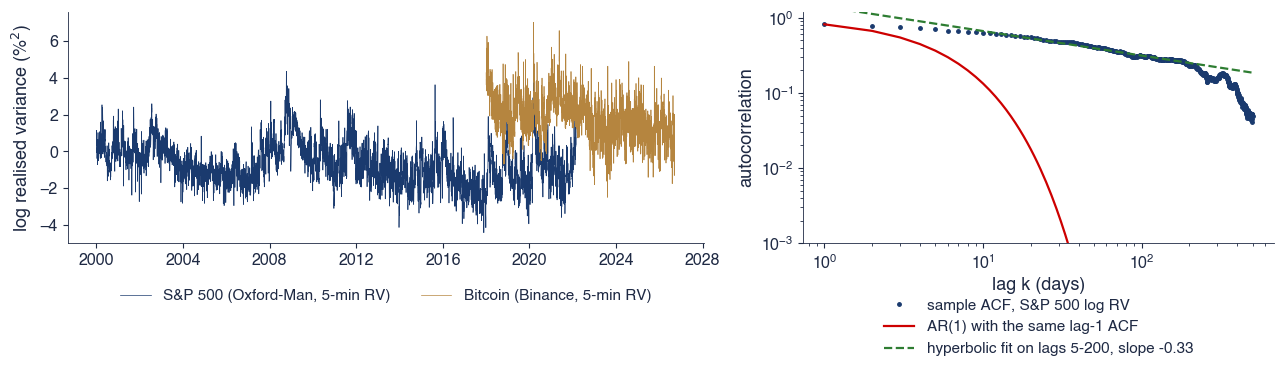

{'n': 5552, 'start': '2000-01-03', 'end': '2022-02-25', 'nb': 3165, 'bstart': '2018-01-02', 'bend': '2026-09-18', 'acf1': 0.8175111249538449, 'acf22': 0.5305318270809716, 'acf250': 0.18360220690306206, 'acf500': 0.049881337213001704, 'ar250': 1.3286721985469372e-22, 'slope': -0.3260695609929543, 'd_acf': 0.3369652195035229}


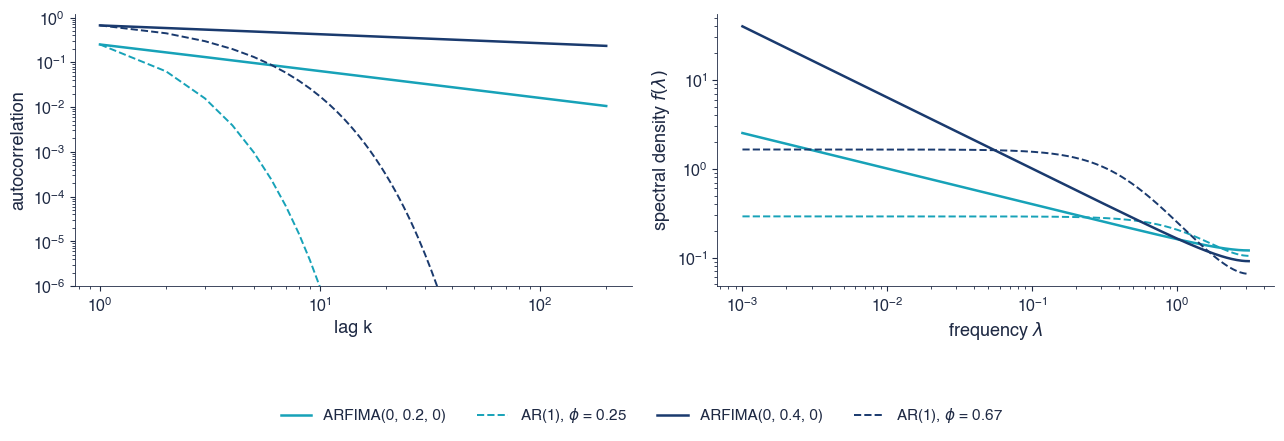

{'0.2': {'r1': 0.25, 'r10': 0.06369081207800725, 'r100': 0.016000939245842942, 'ar100': 6.223015277861142e-61, 'sum100': 3.5082352810836386, 'sum200': 4.783626160380506, 'ratio': 0.25122837539338183}, '0.4': {'r1': 0.6666666666666667, 'r10': 0.4235681566052491, 'r100': 0.2672745700260107, 'ar100': 2.4596544265798566e-18, 'sum100': 33.042958538264266, 'sum200': 57.78537985692931, 'ratio': 0.6310072319130953}}


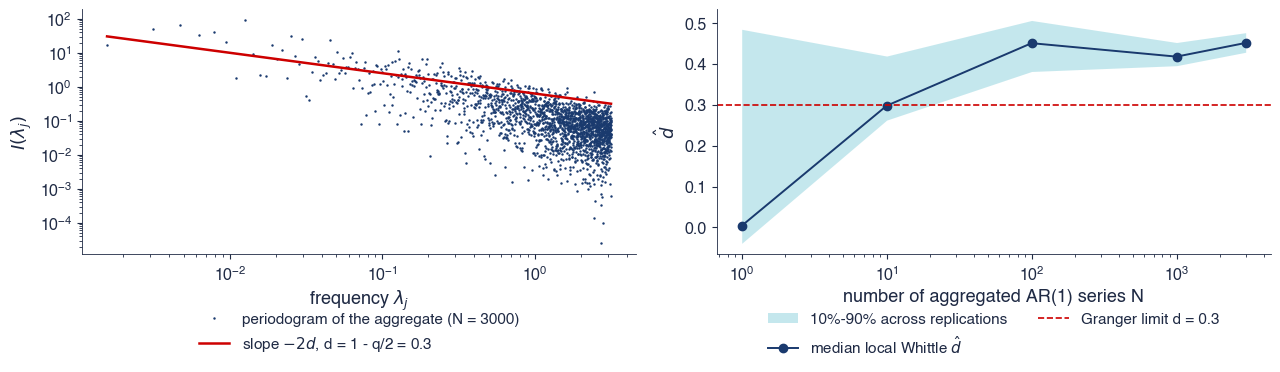

{'d0': 0.30000000000000004, 'q': 1.4, 'n': 4000, 'm': 219, 'reps': 5, 'med': {'1': 0.003987974066055579, '10': 0.29744046361679205, '100': 0.4503550573957048, '1000': 0.41744918207701437, '3000': 0.4509334326261629}, 'lo': {'1': -0.038863401959626204, '10': 0.26227550347131406, '100': 0.3811499465690362, '1000': 0.39531391354572676, '3000': 0.4281548194358253}, 'hi': {'1': 0.4842578795335669, '10': 0.41887408522494046, '100': 0.5058698919621605, '1000': 0.4519763648298428, '3000': 0.47601331334944585}}


In [6]:
def fig_overview(save_it=True, K=500):
    """S&P 500 and Bitcoin log realised variance; the sample ACF of S&P 500 log RV against an AR(1) with the same
    first autocorrelation and a hyperbolic fit c k^(2d - 1) on lags 10-500."""
    s = np.log(rv_series('.SPX'))
    b = np.log(rv_series('btc'))
    acf = sample_acf(s.values, K)
    k = np.arange(1, K + 1)
    sl, ic = np.polyfit(np.log(k[4:200]), np.log(acf[5:201]), 1)          # lags 5-200
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0), gridspec_kw=dict(width_ratios=[1.35, 1]))
    axs[0].plot(s.index, s.values, color=st.MainBlue, lw=0.5, label='S&P 500 (Oxford-Man, 5-min RV)')
    axs[0].plot(b.index, b.values, color=st.Amber, lw=0.5, label='Bitcoin (Binance, 5-min RV)')
    axs[0].set_ylabel('log realised variance (%$^2$)')
    st.legend_outside_bottom(axs[0], ncol=2, y=-0.14)
    axs[1].loglog(k, acf[1:], 'o', ms=2.5, color=st.MainBlue, label='sample ACF, S&P 500 log RV')
    axs[1].loglog(k, acf[1] ** k, color=st.IDAred, lw=1.6, label='AR(1) with the same lag-1 ACF')
    axs[1].loglog(k, np.exp(ic) * k ** sl, '--', color=st.Forest, lw=1.6, label=f'hyperbolic fit on lags 5-200, slope {sl:.2f}')
    axs[1].set_ylim(1e-3, 1.2)
    axs[1].set_xlabel('lag k (days)')
    axs[1].set_ylabel('autocorrelation')
    st.legend_outside_bottom(axs[1], ncol=1, y=-0.18)
    plt.tight_layout()
    save('ats_ch10_overview', save_it)
    return dict(n=len(s), start=str(s.index[0].date()), end=str(s.index[-1].date()), nb=len(b),
                bstart=str(b.index[0].date()), bend=str(b.index[-1].date()), acf1=float(acf[1]), acf22=float(acf[22]),
                acf250=float(acf[250]), acf500=float(acf[500]), ar250=float(acf[1] ** 250), slope=float(sl),
                d_acf=float((sl + 1) / 2))


def fig_acf_spec(save_it=True, K=200):
    """ARFIMA(0, d, 0) against AR(1): autocorrelations (log-log) and spectral densities near frequency zero."""
    k = np.arange(1, K + 1)
    lam = np.logspace(-3, np.log10(np.pi), 300)
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0))
    out = {}
    for d, c in ((0.2, st.Teal), (0.4, st.MainBlue)):
        r = arfima_acf(d, K + 1)
        phi = r[1]
        axs[0].loglog(k, r[1:], color=c, lw=1.8, label=f'ARFIMA(0, {d}, 0)')
        axs[0].loglog(k, phi ** k, '--', color=c, lw=1.4, label=f'AR(1), $\\phi$ = {phi:.2f}')
        f = (2 * np.sin(lam / 2)) ** (-2 * d) / (2 * np.pi)
        fa = 1 / (2 * np.pi * np.abs(1 - phi * np.exp(-1j * lam)) ** 2) * (1 - phi ** 2) * special.gamma(1 - 2 * d) / special.gamma(1 - d) ** 2
        axs[1].loglog(lam, f, color=c, lw=1.8, label='_spec')
        axs[1].loglog(lam, fa, '--', color=c, lw=1.4, label='_spec_ar')
        out[str(d)] = dict(r1=float(r[1]), r10=float(r[10]), r100=float(r[100]), ar100=float(phi ** 100),
                           sum100=float(r[1:101].sum()), sum200=float(r[1:201].sum()),
                           ratio=float(r[100] / r[10]))
    axs[0].set_ylim(1e-6, 1.2)
    axs[0].set_xlabel('lag k')
    axs[0].set_ylabel('autocorrelation')
    axs[1].set_xlabel('frequency $\\lambda$')
    axs[1].set_ylabel('spectral density $f(\\lambda)$')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch10_acf_spec', save_it)
    return out


def aggregate_ar1(N, n, rng, p=1.0, q=1.4):
    """Sum of N independent stationary AR(1) series with phi^2 ~ Beta(p, q) (Granger 1980), scaled by sqrt(N)."""
    phi = np.sqrt(rng.beta(p, q, N))
    x = rng.standard_normal(N) / np.sqrt(1 - phi ** 2)
    out = np.empty(n)
    for t in range(n):
        x = phi * x + rng.standard_normal(N)
        out[t] = x.sum()
    return out / np.sqrt(N)


def fig_aggregation(save_it=True, n=4000, q=1.4, reps=20):
    """Granger (1980): aggregating AR(1) with phi^2 ~ Beta(1, q) gives long memory with d = 1 - q/2."""
    rng = np.random.default_rng(SEED)
    d0 = 1 - q / 2
    m = bandwidth(n, A_BW)
    Ns = [1, 10, 100, 1000, 3000]
    est = {N: [local_whittle(aggregate_ar1(N, n, rng, q=q), m)[0] for _ in range(reps)] for N in Ns}
    x = aggregate_ar1(3000, n, rng, q=q)
    lam, I = periodogram(x, n // 2)
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0))
    axs[0].loglog(lam, I, '.', ms=1.5, color=st.MainBlue, label='periodogram of the aggregate (N = 3000)')
    G = np.mean(lam[:m] ** (2 * d0) * I[:m])
    axs[0].loglog(lam, G * lam ** (-2 * d0), color=st.IDAred, lw=1.8, label=f'slope $-2d$, d = 1 - q/2 = {d0:.1f}')
    axs[0].set_xlabel('frequency $\\lambda_j$')
    axs[0].set_ylabel('$I(\\lambda_j)$')
    st.legend_outside_bottom(axs[0], ncol=1, y=-0.18)
    med = [np.median(est[N]) for N in Ns]
    lo = [np.quantile(est[N], 0.1) for N in Ns]
    hi = [np.quantile(est[N], 0.9) for N in Ns]
    axs[1].fill_between(Ns, lo, hi, color=st.Teal, alpha=0.25, lw=0, label='10%-90% across replications')
    axs[1].semilogx(Ns, med, 'o-', color=st.MainBlue, label='median local Whittle $\\hat d$')
    axs[1].axhline(d0, color=st.IDAred, ls='--', lw=1.2, label=f'Granger limit d = {d0:.1f}')
    axs[1].set_xlabel('number of aggregated AR(1) series N')
    axs[1].set_ylabel('$\\hat d$')
    st.legend_outside_bottom(axs[1], ncol=2, y=-0.18)
    plt.tight_layout()
    save('ats_ch10_aggregation', save_it)
    return dict(d0=d0, q=q, n=n, m=m, reps=reps, med={str(N): float(v) for N, v in zip(Ns, med)},
                lo={str(N): float(v) for N, v in zip(Ns, lo)}, hi={str(N): float(v) for N, v in zip(Ns, hi)})


print(fig_overview(save_it=False))
print(fig_acf_spec(save_it=False))
print(fig_aggregation(save_it=False, reps=5))

## 2. GPH, local Whittle and exact local Whittle by Monte Carlo

- 100 replications here (400 and 300 on the slides).

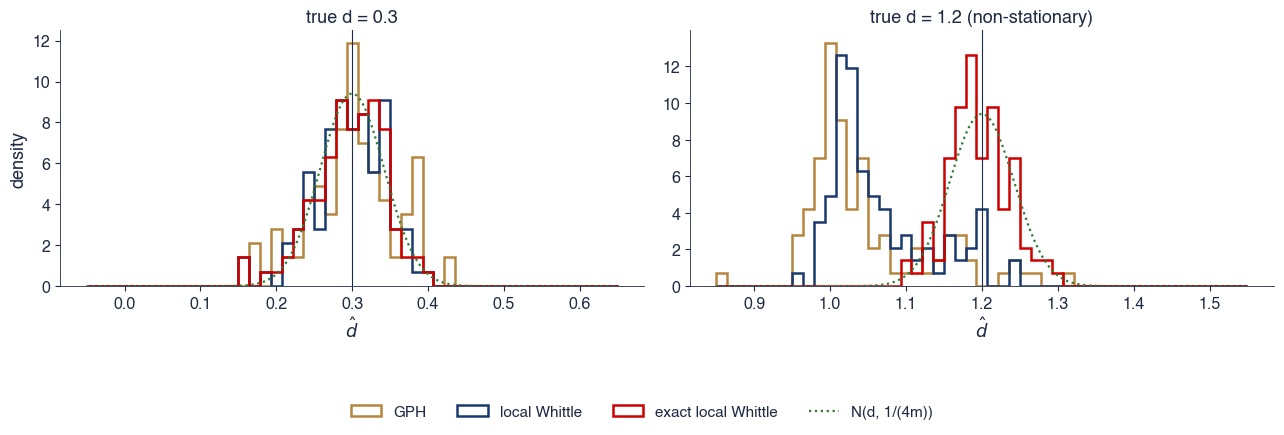

{'n': 2000, 'm': 139, 'reps': 100, 'se_gph': 0.054392228385311, 'se_lw': 0.042409446483998546, '0.3': {'GPH': {'mean': 0.30207377168082855, 'sd': 0.055705865250875355, 'cover': 0.94}, 'LW': {'mean': 0.29522201989386004, 'sd': 0.0469593704233183, 'cover': 0.92}, 'ELW': {'mean': 0.2967224832886883, 'sd': 0.04692061118323158, 'cover': 0.93}}, '1.2': {'GPH': {'mean': 1.0475824613358853, 'sd': 0.08245195132884478, 'cover': 0.22}, 'LW': {'mean': 1.0644437484646745, 'sd': 0.06692634161365951, 'cover': 0.22}, 'ELW': {'mean': 1.1953915297234172, 'sd': 0.04001084934549883, 'cover': 0.95}}}


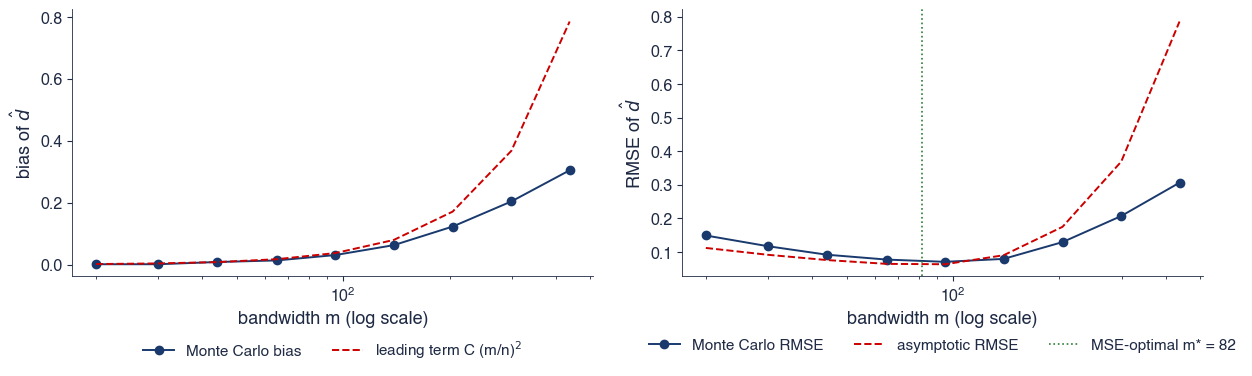

{'n': 2000, 'phi': 0.6, 'd': 0.3, 'reps': 100, 'C': 16.44934066848226, 'mopt': 81.94842328159403, 'aopt': 0.5796798588657641, 'a': [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8], 'm': [20, 30, 44, 65, 95, 139, 204, 299, 437], 'bias': [0.0010384688986579392, 0.0011010968521989425, 0.008253256528286144, 0.013407529025302971, 0.030735042727559878, 0.06269541618336637, 0.12281862729873019, 0.20397760696998657, 0.3046681225078736], 'rmse': [0.14889158030229963, 0.11687883771033349, 0.09168248739343476, 0.07717192075066596, 0.07051391514351278, 0.0792367455628889, 0.12918682734647496, 0.20685193208361458, 0.3060599369768188], 'th_bias': [0.0016449340668482262, 0.0037011016504085088, 0.007961480883545414, 0.01737461608108439, 0.0371138248832631, 0.07945442776393646, 0.1711389403148894, 0.3676468762757456, 0.7853285345298472], 'best_m': 95, 'best_a': 0.6}


In [7]:
def fig_mc_estimators(save_it=True, n=2000, reps=400):
    """Finite-sample distributions of GPH, local Whittle and exact local Whittle (m = n^0.65) for d = 0.3 and for the
    non-stationary d = 1.2, against their asymptotic Normal laws; coverage of the nominal 95% intervals."""
    rng = np.random.default_rng(SEED)
    m = bandwidth(n, A_BW)
    out = dict(n=n, m=m, reps=reps, se_gph=float(np.pi / np.sqrt(24 * m)), se_lw=float(1 / (2 * np.sqrt(m))))
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0))
    for ax, d in zip(axs, (0.3, 1.2)):
        X = sim_arfima(n, d, rng, n_paths=reps)
        E = {'GPH': [], 'LW': [], 'ELW': []}
        for x in X:
            E['GPH'].append(gph(x, m)[0])
            E['LW'].append(local_whittle(x, m)[0])
            E['ELW'].append(elw(x, m)[0])
        res = {}
        bins = np.linspace(d - 0.35, d + 0.35, 50)
        for k, c in (('GPH', st.Amber), ('LW', st.MainBlue), ('ELW', st.IDAred)):
            e = np.array(E[k])
            se = out['se_gph'] if k == 'GPH' else out['se_lw']
            res[k] = dict(mean=float(e.mean()), sd=float(e.std()), cover=float(np.mean(np.abs(e - d) <= 1.96 * se)))
            ax.hist(np.clip(e, bins[0], bins[-1]), bins=bins, density=True, histtype='step', lw=1.8, color=c,
                    label={'GPH': 'GPH', 'LW': 'local Whittle', 'ELW': 'exact local Whittle'}[k])
        g = np.linspace(bins[0], bins[-1], 300)
        ax.plot(g, stats.norm.pdf(g, d, out['se_lw']), ':', color=st.Forest, lw=1.6, label='N(d, 1/(4m))')
        ax.axvline(d, color=st.DarkText, lw=0.8)
        ax.set_title(f'true d = {d}' + (' (non-stationary)' if d > 0.5 else ''))
        ax.set_xlabel('$\\hat d$')
        out[str(d)] = res
    axs[0].set_ylabel('density')
    st.fig_legend_bottom(fig, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ats_ch10_mc_estimators', save_it)
    return out


def fig_bandwidth(save_it=True, n=2000, phi=0.6, d=0.3, reps=300):
    """Local Whittle for ARFIMA(1, 0.3, 0) with phi = 0.6: Monte Carlo bias and RMSE across bandwidths m = n^a,
    against the leading bias C (m/n)^2 and the asymptotic RMSE; the MSE-optimal bandwidth."""
    rng = np.random.default_rng(SEED + 1)
    a_grid = np.round(np.arange(0.40, 0.801, 0.05), 2)
    X = sim_arfima(n, d, rng, phi=phi, n_paths=reps)
    C = lbias_constant(phi)
    bias, rmse, ms = [], [], []
    for a in a_grid:
        m = bandwidth(n, a)
        e = np.array([local_whittle(x, m)[0] for x in X]) - d
        bias.append(e.mean())
        rmse.append(np.sqrt(np.mean(e ** 2)))
        ms.append(m)
    ms = np.array(ms)
    th_b = C * (ms / n) ** 2
    th_r = np.sqrt(th_b ** 2 + 1 / (4 * ms))
    mopt = mse_opt_m(n, C)
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0))
    axs[0].plot(ms, bias, 'o-', color=st.MainBlue, label='Monte Carlo bias')
    axs[0].plot(ms, th_b, '--', color=st.IDAred, label='leading term C (m/n)$^2$')
    axs[0].set_xscale('log')
    axs[0].set_xlabel('bandwidth m (log scale)')
    axs[0].set_ylabel('bias of $\\hat d$')
    st.legend_outside_bottom(axs[0], ncol=2, y=-0.18)
    axs[1].plot(ms, rmse, 'o-', color=st.MainBlue, label='Monte Carlo RMSE')
    axs[1].plot(ms, th_r, '--', color=st.IDAred, label='asymptotic RMSE')
    axs[1].axvline(mopt, color=st.Forest, lw=1.2, ls=':', label=f'MSE-optimal m* = {mopt:.0f}')
    axs[1].set_xscale('log')
    axs[1].set_xlabel('bandwidth m (log scale)')
    axs[1].set_ylabel('RMSE of $\\hat d$')
    st.legend_outside_bottom(axs[1], ncol=3, y=-0.18)
    plt.tight_layout()
    save('ats_ch10_bandwidth', save_it)
    i = int(np.argmin(rmse))
    return dict(n=n, phi=phi, d=d, reps=reps, C=float(C), mopt=float(mopt), aopt=float(np.log(mopt) / np.log(n)),
                a=a_grid.tolist(), m=ms.tolist(), bias=[float(x) for x in bias], rmse=[float(x) for x in rmse],
                th_bias=th_b.tolist(), best_m=int(ms[i]), best_a=float(a_grid[i]))


print(fig_mc_estimators(save_it=False, reps=100))
print(fig_bandwidth(save_it=False, reps=100))

## 3. The Qu test and inflation persistence

- 100 replications here (300 on the slides).

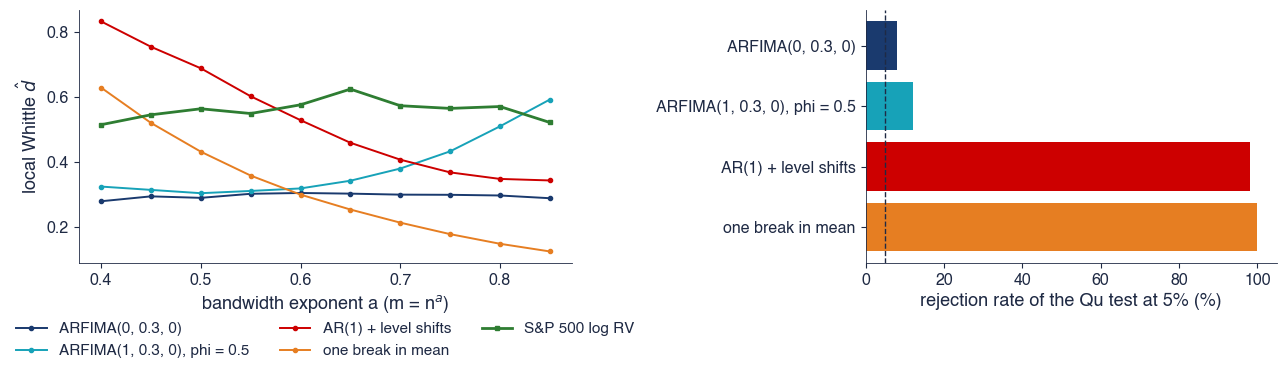

{'ARFIMA(0, 0.3, 0)': 0.08, 'ARFIMA(1, 0.3, 0), phi = 0.5': 0.12, 'AR(1) + level shifts': 0.98, 'one break in mean': 1.0}


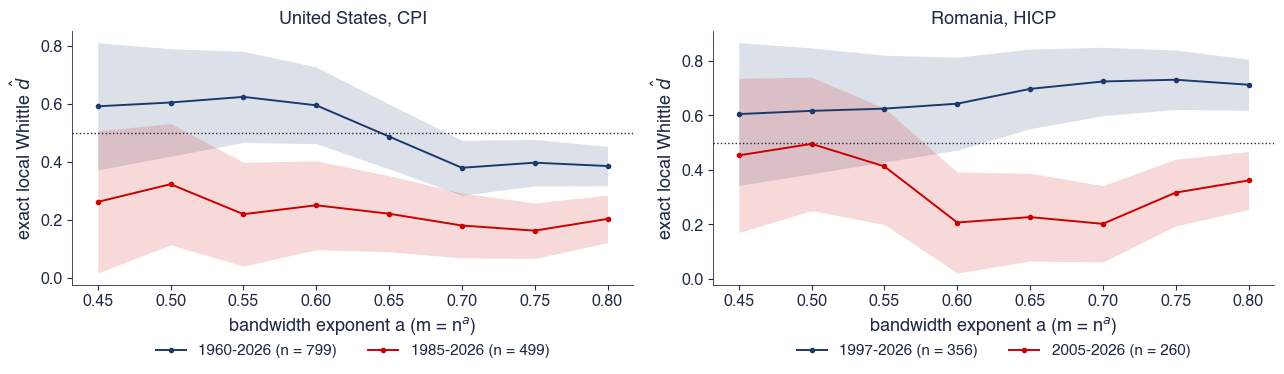

{'crit': {'0.9': 1.0008266016241738, '0.95': 1.136565573228375, '0.99': 1.4534877141433202}, 'us': {'full': {'n': 799, 'start': '1960-01-01', 'end': '2026-08-01', 'd': 0.4872727620512826, 'se': 0.05698028822981897, 'lw': 0.48107263703218234, 'W': 1.6218103165863316, 'mean': 3.6498598934917226, 'curve': [0.5913985263994258, 0.6044790040677401, 0.6238885868591459, 0.5947894476256798, 0.4872727620512826, 0.37963345876885435, 0.3971948943827573, 0.38566942017983374]}, 'post': {'n': 499, 'start': '1985-01-01', 'end': '2026-08-01', 'd': 0.22130957982926083, 'se': 0.0668153104781061, 'lw': 0.2149557653784542, 'W': 0.5531134736840077, 'mean': 2.772317864688627, 'curve': [0.2621049136605873, 0.32305961716641274, 0.21976392991709426, 0.25046308230773273, 0.22130957982926083, 0.18074763646905626, 0.1629962576842692, 0.20349932837367662]}}, 'ro': {'full': {'n': 356, 'start': '1997-01-01', 'end': '2026-08-01', 'd': 0.697148858673467, 'se': 0.07453559924999299, 'lw': 0.31153592072823494, 'W': 0.8604

In [8]:
def qu_designs(n, rng):
    """Data-generating processes of the size and power study (each one path)."""
    return {'ARFIMA(0, 0.3, 0)': lambda: sim_arfima(n, 0.3, rng)[0],
            'ARFIMA(1, 0.3, 0), phi = 0.5': lambda: sim_arfima(n, 0.3, rng, phi=0.5)[0],
            'AR(1) + level shifts': lambda: random_level_shift(n, rng, p=0.004, s_shift=1.0, s_noise=1.0, phi=0.3),
            'one break in mean': lambda: rng.standard_normal(n) + 0.6 * (np.arange(n) >= n // 2)}


def fig_qu(save_it=True, n=2000, reps=300, a=0.7):
    """Qu (2011): simulated critical values; rejection rates at 5% under two long-memory nulls and two short-memory
    alternatives with level shifts; local Whittle d across bandwidths (Perron and Qu 2010), with S&P 500 log RV."""
    crit = {str(e): qu_critical(eps=e) for e in (0.02, 0.05)}
    c5 = crit['0.02']['0.95']
    rng = np.random.default_rng(SEED + 2)
    a_grid = np.round(np.arange(0.40, 0.851, 0.05), 2)
    rej, dbar, curves = {}, {}, {}
    m = bandwidth(n, a)
    for name, gen in qu_designs(n, rng).items():
        W, D, C = [], [], []
        for _ in range(reps):
            x = gen()
            w, d = qu_stat(x, m, 0.02)
            W.append(w)
            D.append(d)
            if len(C) < 100:
                C.append([local_whittle(x, bandwidth(n, aa))[0] for aa in a_grid])
        rej[name] = float(np.mean(np.array(W) > c5))
        dbar[name] = float(np.mean(D))
        curves[name] = np.mean(C, axis=0)
    y = np.log(rv_series('.SPX').values)
    spx = [local_whittle(y, bandwidth(len(y), aa))[0] for aa in a_grid]
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0), gridspec_kw=dict(width_ratios=[1.2, 1]))
    cols = [st.MainBlue, st.Teal, st.IDAred, st.Orange]
    for (name, cv), c in zip(curves.items(), cols):
        axs[0].plot(a_grid, cv, 'o-', ms=3, color=c, label=name)
    axs[0].plot(a_grid, spx, 's-', ms=3, color=st.Forest, lw=2, label='S&P 500 log RV')
    axs[0].set_xlabel('bandwidth exponent a (m = n$^a$)')
    axs[0].set_ylabel('local Whittle $\\hat d$')
    st.legend_outside_bottom(axs[0], ncol=3, y=-0.18)
    names = list(rej)
    axs[1].barh(range(len(names)), [100 * rej[k] for k in names], color=cols)
    axs[1].axvline(5, color=st.DarkText, ls='--', lw=1)
    axs[1].set_yticks(range(len(names)))
    axs[1].set_yticklabels(names)
    axs[1].invert_yaxis()
    axs[1].set_xlabel('rejection rate of the Qu test at 5% (%)')
    plt.tight_layout()
    save('ats_ch10_qu', save_it)
    W_spx = qu_stat(y, bandwidth(len(y), a), 0.02)[0]
    return dict(crit=crit, n=n, reps=reps, m=m, a=a, rej=rej, dbar=dbar, a_grid=a_grid.tolist(),
                curves={k: v.tolist() for k, v in curves.items()}, spx=spx, W_spx=W_spx,
                spx_drop=float(spx[0] - spx[-1]))


def fig_inflation(save_it=True, a=0.65):
    """US and Romanian monthly inflation: exact local Whittle d across bandwidths for the full sample and after the
    disinflation (US from 1985, Romania from 2005); Qu statistics (m = n^0.7, eps = 0.05)."""
    crit = qu_critical(eps=0.05)
    out = dict(crit=crit)
    a_grid = np.round(np.arange(0.45, 0.801, 0.05), 2)
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0))
    for ax, c, cut in zip(axs, ('us', 'ro'), ('1985-01-01', '2005-01-01')):
        x = inflation(c)
        res = {}
        for lab, s, col in (('full', x, st.MainBlue), ('post', x.loc[cut:], st.IDAred)):
            v = s.values
            n = len(v)
            dd = [elw(v, bandwidth(n, aa))[0] for aa in a_grid]
            se = [1 / (2 * np.sqrt(bandwidth(n, aa))) for aa in a_grid]
            lab_t = f'{s.index[0].year}-{s.index[-1].year}'
            ax.fill_between(a_grid, np.array(dd) - 1.96 * np.array(se), np.array(dd) + 1.96 * np.array(se),
                            color=col, alpha=0.15, lw=0)
            ax.plot(a_grid, dd, 'o-', ms=3, color=col, label=f'{lab_t} (n = {n})')
            W = qu_stat(v - v.mean(), bandwidth(n, 0.7), 0.05)[0]
            res[lab] = dict(n=n, start=str(s.index[0].date()), end=str(s.index[-1].date()),
                            d=float(elw(v, bandwidth(n, a))[0]), se=float(1 / (2 * np.sqrt(bandwidth(n, a)))),
                            lw=float(local_whittle(v, bandwidth(n, a))[0]), W=float(W), mean=float(v.mean()),
                            curve=[float(z) for z in dd])
        ax.axhline(0.5, color=st.DarkText, ls=':', lw=1)
        ax.set_title({'us': 'United States, CPI', 'ro': 'Romania, HICP'}[c])
        ax.set_xlabel('bandwidth exponent a (m = n$^a$)')
        ax.set_ylabel('exact local Whittle $\\hat d$')
        st.legend_outside_bottom(ax, ncol=2, y=-0.18)
        out[c] = res
    plt.tight_layout()
    save('ats_ch10_inflation', save_it)
    out['a_grid'] = a_grid.tolist()
    return out


print(fig_qu(save_it=False, reps=100)['rej'])
print(fig_inflation(save_it=False))

## 4. Fractional cointegration: realised and implied variance

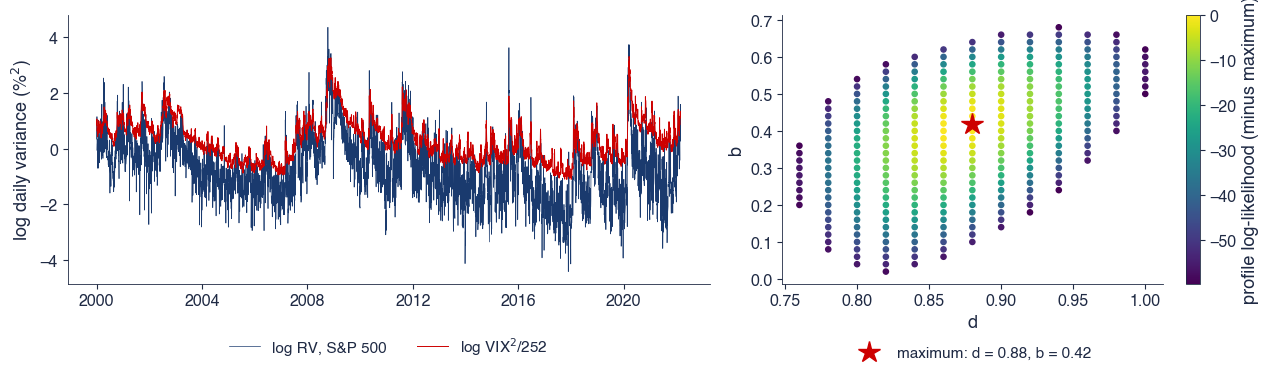

{'d': np.float64(0.88), 'b': np.float64(0.42), 'beta': [1.0, -1.7020588984344978], 'alpha': [-1.5454597851907128, 0.005563361871689903], 'trace0': np.float64(1453.935043946265), 'p0': 0.0, 'trace1': np.float64(18.255171377146326), 'p1': 1.932007118805793e-05}


In [9]:
def rv_vix():
    """S&P 500 log realised variance (OMI, 5-min) and log VIX^2/252 (daily %^2), common days."""
    rv = rv_series('.SPX')
    vix = load_close('vix', start='2000-01-01')
    df = pd.concat([np.log(rv), np.log(vix ** 2 / 252)], axis=1, keys=['rv', 'iv']).dropna()
    return df


def fig_fcvar(save_it=True):
    """FCVAR with k = 0 (Johansen and Nielsen 2012) of (log RV, log VIX^2): profile likelihood over (d, b), rank tests,
    the cointegrating vector; local Whittle d of each series and of the spread; narrow-band least squares."""
    df = rv_vix()
    X = df[['rv', 'iv']].values
    f = fcvar_fit(X, np.round(np.arange(0.30, 1.001, 0.02), 2))
    n = len(df)
    m = bandwidth(n, A_BW)
    beta2 = -f['beta'][1]
    spread = df['rv'].values - beta2 * df['iv'].values
    out = dict(n=n, start=str(df.index[0].date()), end=str(df.index[-1].date()), m=m,
               d_rv=local_whittle(df['rv'].values, m)[0], d_iv=local_whittle(df['iv'].values, m)[0],
               d_spread=local_whittle(spread, m)[0], se=1 / (2 * np.sqrt(m)),
               nbls=nbls(df['rv'].values, df['iv'].values, bandwidth(n, 0.6)),
               **{k: v for k, v in f.items() if k != 'surf'})
    out['beta2'] = beta2
    S = f['surf']
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0), gridspec_kw=dict(width_ratios=[1.35, 1]))
    axs[0].plot(df.index, df['rv'], color=st.MainBlue, lw=0.5, label='log RV, S&P 500')
    axs[0].plot(df.index, df['iv'], color=st.IDAred, lw=0.7, label='log VIX$^2$/252')
    axs[0].set_ylabel('log daily variance (%$^2$)')
    st.legend_outside_bottom(axs[0], ncol=2, y=-0.14)
    sel = S[:, 2] > S[:, 2].max() - 60
    sc = axs[1].scatter(S[sel, 0], S[sel, 1], c=S[sel, 2] - S[:, 2].max(), s=14, cmap='viridis')
    axs[1].plot([f['d']], [f['b']], '*', ms=16, color=st.IDAred, label=f'maximum: d = {f["d"]:.2f}, b = {f["b"]:.2f}')
    plt.colorbar(sc, ax=axs[1], label='profile log-likelihood (minus maximum)')
    axs[1].set_xlabel('d')
    axs[1].set_ylabel('b')
    st.legend_outside_bottom(axs[1], ncol=1, y=-0.18)
    plt.tight_layout()
    save('ats_ch10_fcvar', save_it)
    return out


r = fig_fcvar(save_it=False)
print({k: r[k] for k in ('d', 'b', 'beta', 'alpha', 'trace0', 'p0', 'trace1', 'p1')})

## 5. Long memory in volatility: FIGARCH, proxies, HAR

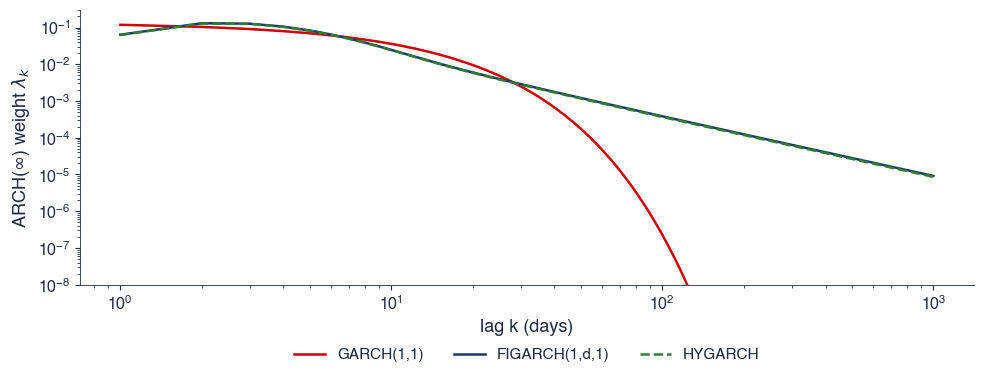

{'par': [0.028903419374788, 0.6120464247210928, 0.041381323172440226, 0.589793358784177, 6.413720872664596], 'll': -9060.600974468585, 'bic': 18165.26169982487, 'k': 5, 'w22': 0.14743294644673197, 'w250': 0.0202884456357632, 'sum': 0.9850996179602768}


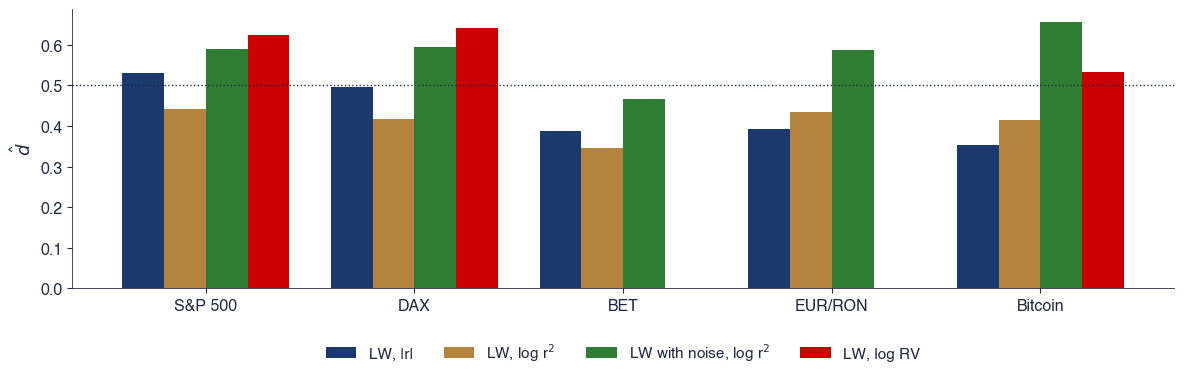

{'crit': {'0.9': 1.089403671790751, '0.95': 1.218153631241267, '0.99': 1.5596071325332495}, 'a': 0.65, 'sp500': {'n': 6714, 'm': 307, 'abs': 0.5305899466293147, 'lsq': 0.44246630072812354, 'lwn': 0.5892094494926985, 'qu': 0.7799737237801271, 'zeros': 0.0, 'rv': 0.623764471715914, 'n_rv': 5552, 'qu_rv': 0.6601568850618882}, 'dax': {'n': 6786, 'm': 309, 'abs': 0.4952734653778757, 'lsq': 0.4182056759623888, 'lwn': 0.5941348725776724, 'qu': 0.7162003203756219, 'zeros': 0.0, 'rv': 0.6412477060467712, 'n_rv': 5614, 'qu_rv': 0.4907471059600777}, 'bet': {'n': 6670, 'm': 305, 'abs': 0.38681554340514074, 'lsq': 0.34481327284033453, 'lwn': 0.466404900576097, 'qu': 1.7101525920614284, 'zeros': 0.0}, 'eurron': {'n': 5352, 'm': 265, 'abs': 0.39307544661298466, 'lsq': 0.43500222676617867, 'lwn': 0.5873479097770342, 'qu': 1.8829102392938282, 'zeros': 0.002242152466367713}, 'btc': {'n': 4384, 'm': 232, 'abs': 0.3531331357821437, 'lsq': 0.41472699917684475, 'lwn': 0.6554791185821973, 'qu': 0.78898196730

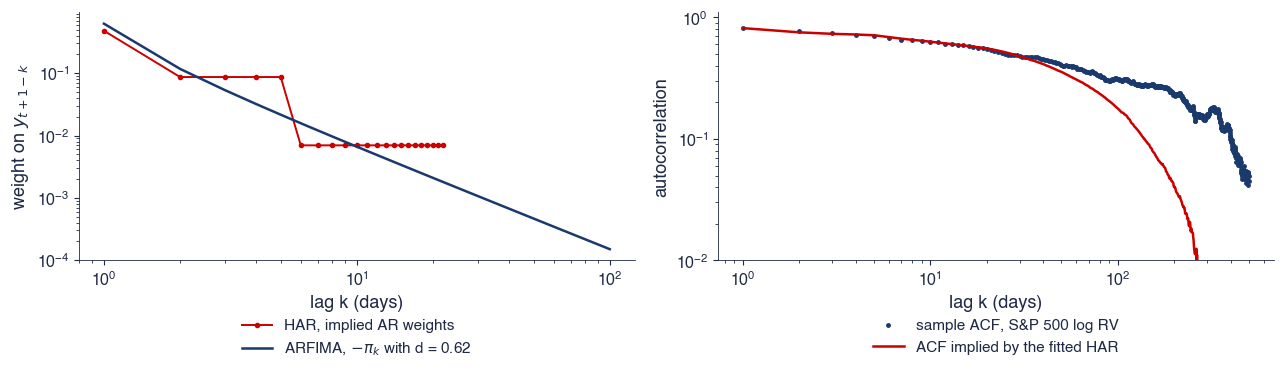

{'b': [-0.037706821124891036, 0.3932431665148999, 0.3993499802688423, 0.1530860642299045], 'd': 0.623764471715914, 'persistence': 0.9456792110136469, 'acf_s': {'k22': 0.5305318270809716, 'k100': 0.31099665698813933, 'k250': 0.18360220690306206, 'k500': 0.049881337213001704}, 'acf_h': {'k22': 0.5410773680680468, 'k100': 0.1786345506792948, 'k250': 0.017048380373607504, 'k500': -0.013503159439324583}, 'half_lag': 112, 'pi': {'k1': 0.623764471715914, 'k5': 0.02159305934830141, 'k22': 0.0017867346855303062, 'k100': 0.0001500880505605161}}


In [10]:
def fig_figarch(save_it=True, K=1000):
    """GARCH(1,1), FIGARCH(1,d,1) and HYGARCH with Student t innovations for the S&P 500, BET and Bitcoin; the ARCH
    weights of the S&P 500 models."""
    out = {}
    for nm, s0 in VOL_ASSETS.items():
        r = returns(nm, start=s0).values
        out[nm] = {k: ltm_fit(r, k, K) for k in ('garch', 'figarch', 'hygarch')}
        out[nm]['n'] = len(r)
        for k in ('garch', 'figarch', 'hygarch'):
            p = out[nm][k]['par']
            lam = (arch_inf_weights('garch', (p[1], p[2]), K) if k == 'garch' else
                   arch_inf_weights(k, tuple(p[1:4]) if k == 'figarch' else tuple(p[1:5]), K))
            out[nm][k]['w22'] = float(lam[22:].sum() / lam.sum())
            out[nm][k]['w250'] = float(lam[250:].sum() / lam.sum())
            out[nm][k]['sum'] = float(lam.sum())
            if nm == 'sp500':
                out[nm][k]['lam'] = lam
        out[nm]['lr_fig_garch'] = 2 * (out[nm]['figarch']['ll'] - out[nm]['garch']['ll'])
        out[nm]['lr_hy_fig'] = 2 * (out[nm]['hygarch']['ll'] - out[nm]['figarch']['ll'])
    k = np.arange(1, K + 1)
    fig, ax = plt.subplots(figsize=(10, 4.0))
    for m_, c, lab in (('garch', st.IDAred, 'GARCH(1,1)'), ('figarch', st.MainBlue, 'FIGARCH(1,d,1)'),
                       ('hygarch', st.Forest, 'HYGARCH')):
        lam = out['sp500'][m_].pop('lam')
        ax.loglog(k, np.clip(lam, 1e-12, None), color=c, lw=1.8, ls='--' if m_ == 'hygarch' else '-', label=lab)
    ax.set_ylim(1e-8, 0.3)
    ax.set_xlabel('lag k (days)')
    ax.set_ylabel('ARCH($\\infty$) weight $\\lambda_k$')
    st.legend_outside_bottom(ax, ncol=3, y=-0.18)
    plt.tight_layout()
    save('ats_ch10_figarch', save_it)
    return out


def logsq(r):
    """log(r^2 + c) with c = 1% of the sample variance (guards against zero returns)."""
    r = np.asarray(r, float)
    return np.log(r ** 2 + 0.01 * r.var())


def fig_assets_d(save_it=True, a=A_BW):
    """Long memory of volatility proxies: local Whittle d of |r| and log r^2, the noise-robust estimator of Hurvich,
    Moulines and Soulier (2005) on log r^2, and local Whittle on log RV where realised measures exist; Qu test on |r|."""
    crit = qu_critical(eps=0.02)
    out = dict(crit=crit, a=a)
    rows = []
    for nm, (lab, s0, rvk) in ASSETS_D.items():
        r = returns(nm, start=s0).values
        n = len(r)
        m = bandwidth(n, a)
        res = dict(n=n, m=m, abs=local_whittle(np.abs(r), m)[0], lsq=local_whittle(logsq(r), m)[0],
                   lwn=lwn(logsq(r), bandwidth(n, 0.8))[0], qu=qu_stat(np.abs(r), bandwidth(n, 0.7), 0.02)[0],
                   zeros=float(np.mean(r == 0)))
        if rvk:
            y = np.log(rv_series(rvk).values)
            res['rv'] = local_whittle(y, bandwidth(len(y), a))[0]
            res['n_rv'] = len(y)
            res['qu_rv'] = qu_stat(y, bandwidth(len(y), 0.7), 0.02)[0]
        out[nm] = res
        rows.append((lab, res))
    fig, ax = plt.subplots(figsize=(12, 4.0))
    w = 0.2
    x = np.arange(len(rows))
    for i, (key, c, lab) in enumerate((('abs', st.MainBlue, 'LW, |r|'), ('lsq', st.Amber, 'LW, log r$^2$'),
                                       ('lwn', st.Forest, 'LW with noise, log r$^2$'), ('rv', st.IDAred, 'LW, log RV'))):
        vals = [res.get(key, np.nan) for _, res in rows]
        ax.bar(x + (i - 1.5) * w, vals, w, color=c, label=lab)
    ax.axhline(0.5, color=st.DarkText, ls=':', lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels([lab for lab, _ in rows])
    ax.set_ylabel('$\\hat d$')
    st.legend_outside_bottom(ax, ncol=4, y=-0.14)
    plt.tight_layout()
    save('ats_ch10_assets_d', save_it)
    return out


def har_fit_full(y, h=1):
    """OLS of y_{t+h} on the HAR regressors (full sample)."""
    t, X = har_design(y)
    keep = t + h < len(y)
    b = np.linalg.lstsq(X[keep], y[t[keep] + h], rcond=None)[0]
    u = y[t[keep] + h] - X[keep] @ b
    return b, float(u.var())


def fig_har_approx(save_it=True, K=500, n_sim=200_000):
    """HAR as an approximation of long memory (Corsi 2009): implied AR weights against ARFIMA pi-weights; the ACF
    implied by the fitted HAR against the sample ACF of S&P 500 log RV."""
    y = np.log(rv_series('.SPX').values)
    b, s2 = har_fit_full(y, 1)
    w = har_ar_weights(b[1:])
    m = bandwidth(len(y), A_BW)
    d = local_whittle(y, m)[0]
    pi = -frac_weights(d, 101)[1:]
    rng = np.random.default_rng(SEED + 3)
    e = rng.standard_normal(n_sim + 2000) * np.sqrt(s2)
    from scipy import signal as sg
    sim = sg.lfilter([1.0], np.concatenate([[1.0], -w]), e)[2000:]
    acf_h = sample_acf(sim, K)
    acf_s = sample_acf(y, K)
    k = np.arange(1, K + 1)
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0))
    kk = np.arange(1, 101)
    axs[0].loglog(kk[:22], w, 'o-', ms=3, color=st.IDAred, label='HAR, implied AR weights')
    axs[0].loglog(kk, pi, color=st.MainBlue, lw=1.8, label=f'ARFIMA, $-\\pi_k$ with d = {d:.2f}')
    axs[0].set_xlabel('lag k (days)')
    axs[0].set_ylabel('weight on $y_{t+1-k}$')
    st.legend_outside_bottom(axs[0], ncol=1, y=-0.18)
    axs[1].loglog(k, acf_s[1:], 'o', ms=2.5, color=st.MainBlue, label='sample ACF, S&P 500 log RV')
    axs[1].loglog(k, np.clip(acf_h[1:], 1e-4, None), color=st.IDAred, lw=1.8, label='ACF implied by the fitted HAR')
    axs[1].set_ylim(1e-2, 1.1)
    axs[1].set_xlabel('lag k (days)')
    axs[1].set_ylabel('autocorrelation')
    st.legend_outside_bottom(axs[1], ncol=1, y=-0.18)
    plt.tight_layout()
    save('ats_ch10_har_approx', save_it)
    gap = np.where(acf_h[1:] < 0.5 * acf_s[1:])[0]
    return dict(b=b.tolist(), d=d, persistence=float(w.sum()), acf_s=dict(k22=float(acf_s[22]), k100=float(acf_s[100]), k250=float(acf_s[250]), k500=float(acf_s[500])),
                acf_h=dict(k22=float(acf_h[22]), k100=float(acf_h[100]), k250=float(acf_h[250]), k500=float(acf_h[500])),
                half_lag=int(gap[0] + 1) if len(gap) else None, pi=dict(k1=float(pi[0]), k5=float(pi[4]), k22=float(pi[21]), k100=float(pi[99])))


print(fig_figarch(save_it=False)['sp500']['figarch'])
print(fig_assets_d(save_it=False))
print(fig_har_approx(save_it=False))

## 6. Rough volatility: fBm, the hybrid scheme, the scaling, measurement error, two scales

- 3 replications of the measurement-error simulation here (8 on the slides).

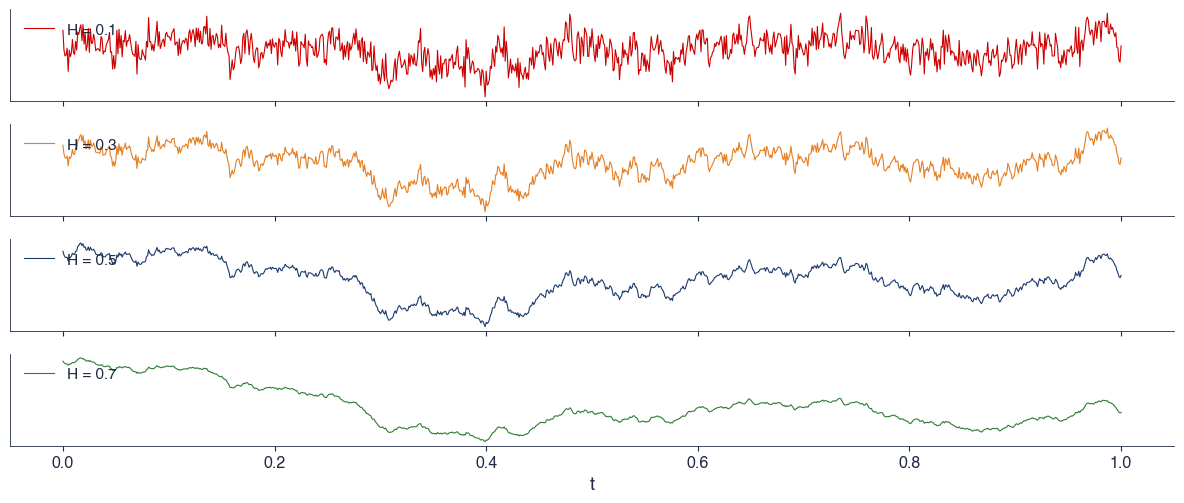

{'0.1': {'rho1': -0.42565082250148245, 'eig_min': 0.0007818610677974291}, '0.3': {'rho1': -0.242141716744801, 'eig_min': 0.037514661804607385}, '0.5': {'rho1': 0.0, 'eig_min': 1.0}, '0.7': {'rho1': 0.3195079107728942, 'eig_min': 0.5777901244261281}}


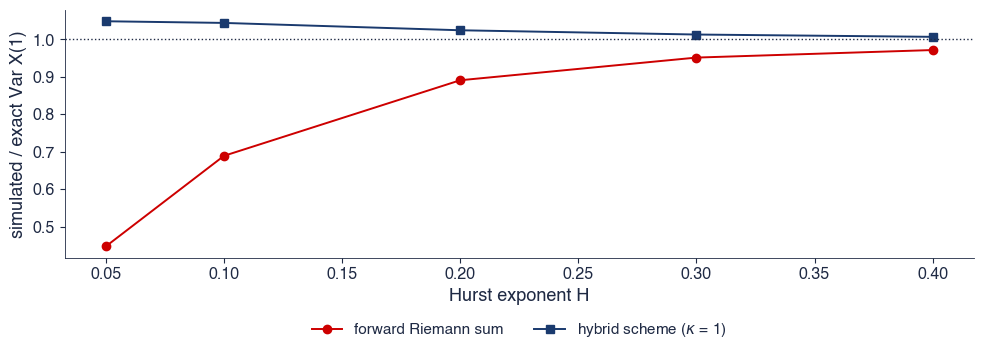

{'n': 250, 'paths': 4000, 'H': [0.05, 0.1, 0.2, 0.3, 0.4], 'riemann': [0.4469827794354632, 0.6889886778945136, 0.8910636224536044, 0.9516550197797433, 0.9718086973744111], 'hybrid': [1.048778303138151, 1.0443188360436888, 1.0246814844287955, 1.0132852499897123, 1.0071306936527766]}


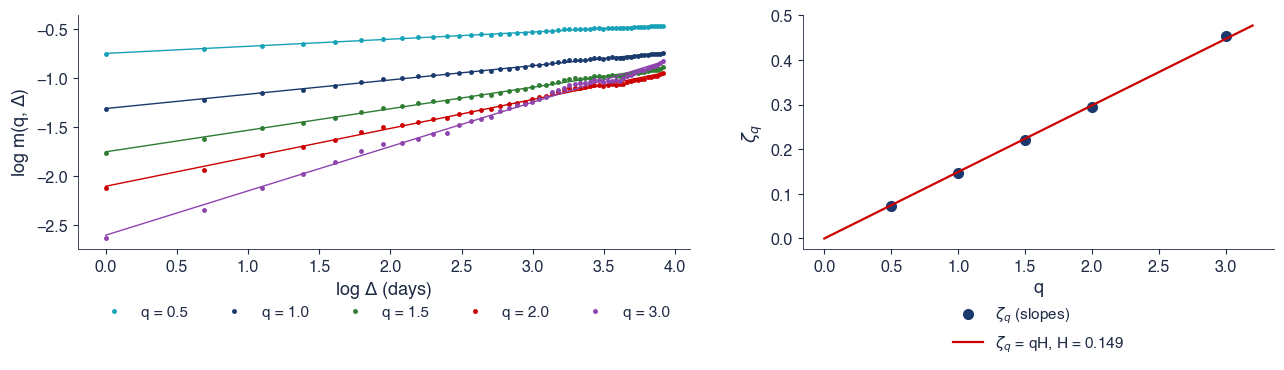

{'n': 5552, 'zeta': [0.07277749943221044, 0.14581943691749213, 0.21970698017798584, 0.29506995557356447, 0.4522616462549928], 'H': 0.14901172768561718, 'H2': 0.14753497778678223, 'nu': 0.3498659000180723, 'qs': [0.5, 1.0, 1.5, 2.0, 3.0], 'sub': {'2000-2010': 0.13981688637316514, '2011-2022': 0.15464266525900927}, 'c': 0.7068993078006534, 'lin_icpt': -0.005760108195860183}


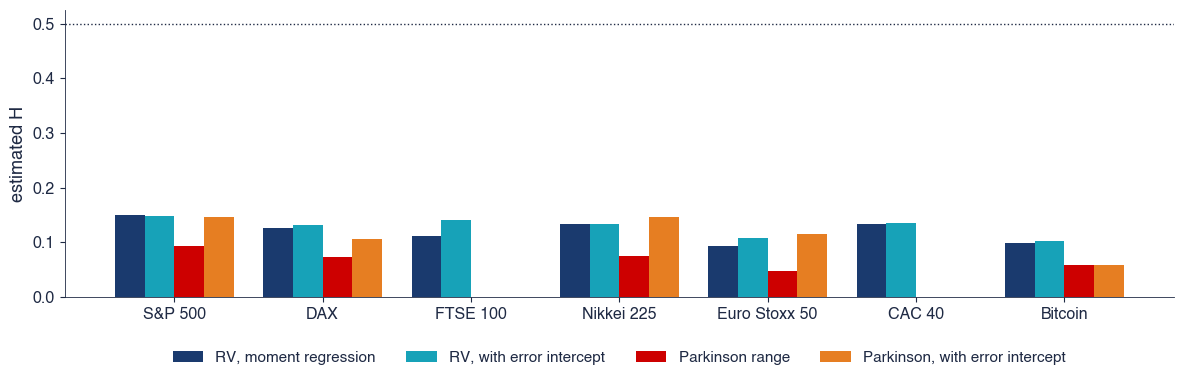

{'.SPX': {'n': 5552, 'H': 0.14901172768561718, 'nu': 0.3498659000180723, 'Hn': 0.14753497701136253, 'share': 3.382659072650249e-12, 'd': 0.623764471715914, 'Hp': 0.09329499382674983, 'Hpn': 0.14567097278590965, 'sharep': 0.5165862977029098}, '.GDAXI': {'n': 5614, 'H': 0.12657273971025365, 'nu': 0.3095459639214003, 'Hn': 0.131448046607173, 'share': 0.004491514826825628, 'd': 0.6412477060467712, 'Hp': 0.0733226196090173, 'Hpn': 0.10618530723715792, 'sharep': 0.41940104636389774}, '.FTSE': {'n': 5586, 'H': 0.11149154149355935, 'nu': 0.3477436608316988, 'Hn': 0.13993003602222465, 'share': 0.3098369983238109, 'd': 0.63217037573894}, '.N225': {'n': 5381, 'H': 0.1336680297699095, 'nu': 0.3160530191707829, 'Hn': 0.1342241738328921, 'share': 4.8290631087162974e-09, 'd': 0.6209840495943058, 'Hp': 0.07415551019161609, 'Hpn': 0.14600143638952848, 'sharep': 0.6786972794891979}, '.STOXX50E': {'n': 5635, 'H': 0.0927516777117364, 'nu': 0.3836352120087559, 'Hn': 0.1086460251372105, 'share': 2.300618228

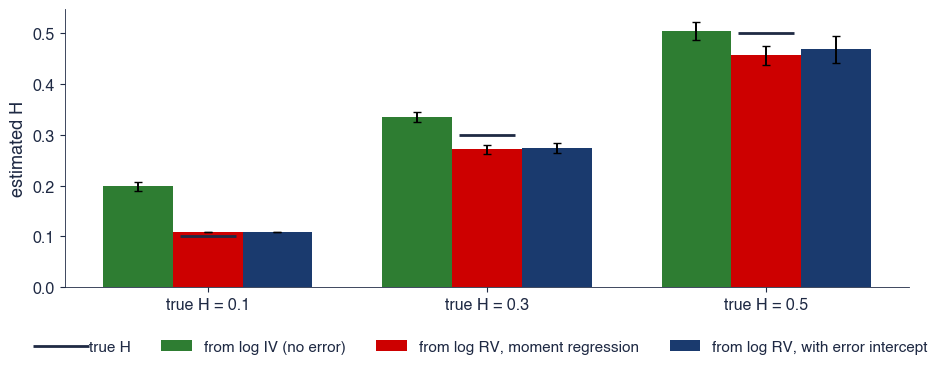

{'0.1': {'iv': {'mean': 0.19882418633088628, 'sd': 0.009157253857625386}, 'rv': {'mean': 0.10861404700565915, 'sd': 0.0006396860314203207}, 'rvn': {'mean': 0.1088646777251291, 'sd': 0.0006711835475387984}}, '0.3': {'iv': {'mean': 0.3349426631820584, 'sd': 0.009269234886779186}, 'rv': {'mean': 0.271757726247782, 'sd': 0.009171889741368944}, 'rvn': {'mean': 0.27372480525155424, 'sd': 0.009995598568869004}}, '0.5': {'iv': {'mean': 0.5040870644709702, 'sd': 0.017678605266897896}, 'rv': {'mean': 0.4570328217273662, 'sd': 0.01906114317768533}, 'rvn': {'mean': 0.46836601077397355, 'sd': 0.02676658290259651}}, 'design': {'n_days': 2500, 'reps': 3, 'M': 78}}


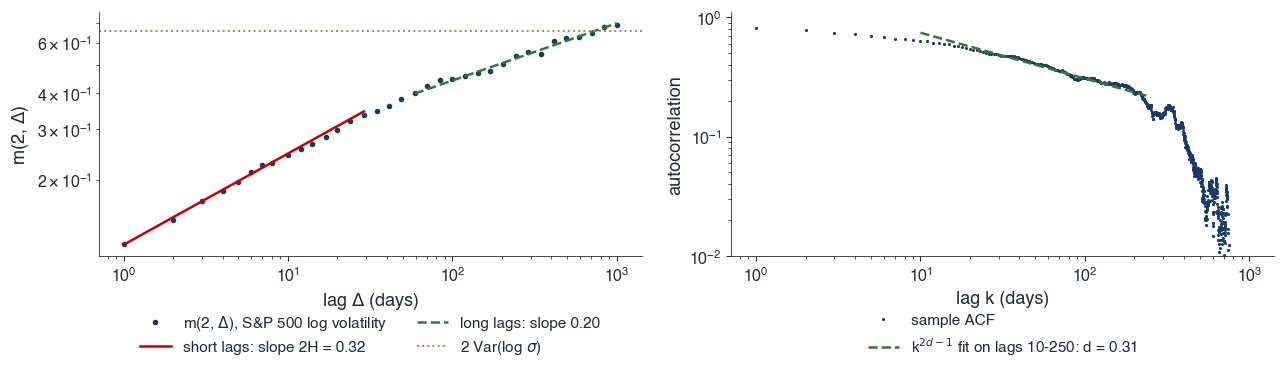

{'H_short': 0.1589544308610578, 'slope_long': 0.1994869208044129, 'd_acf': 0.30809269444052134, 'd_long': 0.5997434604022065, 'acf1000': -0.031176200609244174, 'd_lw': 0.5632084682500191, 'm_lw': 74, 'var2': 0.6563758958636546, 'm2_1000': 0.6890287299036187}


In [11]:
def fig_fbm_paths(save_it=True, n=1000):
    """Fractional Brownian motion with H = 0.1, 0.3, 0.5, 0.7 (circulant embedding)."""
    fig, axs = plt.subplots(4, 1, figsize=(12, 5.2), sharex=True)
    out = {}
    for ax, H, c in zip(axs, (0.1, 0.3, 0.5, 0.7), (st.IDAred, st.Orange, st.MainBlue, st.Forest)):
        B = fbm(n, H, np.random.default_rng(SEED), 1)[0]
        ax.plot(np.linspace(0, 1, n + 1), B, color=c, lw=0.8, label=f'H = {H}')
        ax.set_yticks([])
        ax.legend(loc='upper left', frameon=False)
        out[str(H)] = dict(rho1=float(fgn_acov(H, 2)[1]), eig_min=float(circulant_eigs(fgn_acov(H, 2 ** 10)).min()))
    axs[-1].set_xlabel('t')
    plt.tight_layout()
    save('ats_ch10_fbm_paths', save_it)
    return out


def fig_hybrid(save_it=True, n=250, paths=4000):
    """Variance of X(1) for the Riemann-Liouville process: forward Riemann sum against the hybrid scheme of
    Bennedsen, Lunde and Pakkanen (2017), relative to the exact value 1/(2H)."""
    Hs = np.array([0.05, 0.1, 0.2, 0.3, 0.4])
    out = dict(n=n, paths=paths, H=Hs.tolist(), riemann=[], hybrid=[])
    for H in Hs:
        rng = np.random.default_rng(SEED)
        ex = 1 / (2 * H)
        out['riemann'].append(float(hybrid_rl(n, H, rng, paths, kappa=0)[:, -1].var() / ex))
        out['hybrid'].append(float(hybrid_rl(n, H, rng, paths, kappa=1)[:, -1].var() / ex))
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(Hs, out['riemann'], 'o-', color=st.IDAred, label='forward Riemann sum')
    ax.plot(Hs, out['hybrid'], 's-', color=st.MainBlue, label='hybrid scheme ($\\kappa$ = 1)')
    ax.axhline(1, color=st.DarkText, ls=':', lw=1)
    ax.set_xlabel('Hurst exponent H')
    ax.set_ylabel('simulated / exact Var X(1)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    plt.tight_layout()
    save('ats_ch10_hybrid', save_it)
    return out


def fig_gjr(save_it=True):
    """Gatheral, Jaisson and Rosenbaum (2018) on S&P 500 5-minute RV: log m(q, Delta) against log Delta, and zeta_q
    against q; H by subsample."""
    s = rv_series('.SPX')
    x = 0.5 * np.log(s.values)
    g = gjr_scaling(x, LAGS, QS)
    lg = np.log(np.array(LAGS, float))
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0), gridspec_kw=dict(width_ratios=[1.3, 1]))
    cols = [st.Teal, st.MainBlue, st.Forest, st.IDAred, st.Purple]
    for q, c in zip(QS, cols):
        y = np.log(variogram(x, LAGS, q))
        axs[0].plot(lg, y, 'o', ms=2.5, color=c, label=f'q = {q}')
        bq, aq = np.polyfit(lg, y, 1)
        axs[0].plot(lg, aq + bq * lg, color=c, lw=1)
    axs[0].set_xlabel('log $\\Delta$ (days)')
    axs[0].set_ylabel('log m(q, $\\Delta$)')
    st.legend_outside_bottom(axs[0], ncol=5, y=-0.18)
    axs[1].plot(QS, g['zeta'], 'o', ms=7, color=st.MainBlue, label='$\\zeta_q$ (slopes)')
    qq = np.linspace(0, 3.2, 50)
    axs[1].plot(qq, g['H'] * qq, color=st.IDAred, lw=1.6, label=f'$\\zeta_q$ = qH, H = {g["H"]:.3f}')
    axs[1].set_xlabel('q')
    axs[1].set_ylabel('$\\zeta_q$')
    st.legend_outside_bottom(axs[1], ncol=1, y=-0.18)
    plt.tight_layout()
    save('ats_ch10_gjr', save_it)
    sub = {}
    for lab, a, b in (('2000-2010', '2000-01-01', '2010-12-31'), ('2011-2022', '2011-01-01', '2022-12-31')):
        xx = 0.5 * np.log(s.loc[a:b].values)
        sub[lab] = gjr_scaling(xx, LAGS, QS)['H']
    lin = np.polyfit(QS, g['zeta'], 1)
    return dict(n=len(s), **g, sub=sub, c=float(rfsv_c(g['H'])), lin_icpt=float(lin[1]))


def fig_gjr_assets(save_it=True):
    """H of six OMI indices and Bitcoin: moment regression (GJR), with a measurement-error intercept, and from the
    Parkinson range of daily OHLC prices (EODHD) over the same days."""
    rows = {}
    pk = {'.SPX': 'sp500', '.GDAXI': 'dax', '.STOXX50E': 'stoxx50', '.N225': 'nikkei', 'btc': 'btc'}
    for k in list(OMI_NAMES) + ['btc']:
        s = rv_series(k)
        x = 0.5 * np.log(s.values)
        g = gjr_scaling(x, LAGS, QS)
        hn = h_with_noise(x, LAGS)
        r = dict(n=len(s), H=g['H'], nu=g['nu'], Hn=hn['H'], share=hn['share'], d=local_whittle(2 * x, bandwidth(len(x), A_BW))[0])
        if k in pk:
            p = parkinson(pk[k], start=str(s.index[0].date()))
            p = p.loc[:s.index[-1]]
            xp = 0.5 * np.log(p.values)
            r['Hp'] = gjr_scaling(xp, LAGS, QS)['H']
            r['Hpn'] = h_with_noise(xp, LAGS)['H']
            r['sharep'] = h_with_noise(xp, LAGS)['share']
        rows[k] = r
    labs = [OMI_NAMES.get(k, 'Bitcoin') for k in rows]
    x_ = np.arange(len(rows))
    fig, ax = plt.subplots(figsize=(12, 4.0))
    w = 0.2
    for i, (key, c, lab) in enumerate((('H', st.MainBlue, 'RV, moment regression'), ('Hn', st.Teal, 'RV, with error intercept'),
                                       ('Hp', st.IDAred, 'Parkinson range'), ('Hpn', st.Orange, 'Parkinson, with error intercept'))):
        ax.bar(x_ + (i - 1.5) * w, [rows[k].get(key, np.nan) for k in rows], w, color=c, label=lab)
    ax.axhline(0.5, color=st.DarkText, ls=':', lw=1)
    ax.set_xticks(x_)
    ax.set_xticklabels(labs)
    ax.set_ylabel('estimated H')
    st.legend_outside_bottom(ax, ncol=4, y=-0.14)
    plt.tight_layout()
    save('ats_ch10_gjr_assets', save_it)
    return rows


def sim_sv_rv(H, n_days, rng, M=78, kappa=0.01, eta=0.15, mean_logv=0.0):
    """Log volatility as a fractional OU on an intraday grid (M steps a day, mean reversion kappa per day, daily
    increment s.d. eta), intraday returns sigma dW: daily integrated variance IV and realised variance RV."""
    N = n_days * M
    dt = 1.0 / M
    g = circulant_sim(fgn_acov(H, N), rng, 1)[0] * eta * dt ** H
    x = lfilter([1.0], [1.0, -(1 - kappa * dt)], g)          # x_i = (1 - kappa dt) x_{i-1} + g_i
    sig2 = np.exp(2 * (x + mean_logv))
    r2 = sig2 * dt * rng.standard_normal(N) ** 2
    IV = (sig2 * dt).reshape(n_days, M).sum(1)
    RV = r2.reshape(n_days, M).sum(1)
    return IV, RV


def fig_noise_sim(save_it=True, n_days=2500, reps=8):
    """Measurement error and roughness: H estimated from log IV (true), from log RV (78 intraday returns), and from log
    RV with the error intercept, when the true log volatility has H = 0.1, 0.3 or 0.5."""
    rng = np.random.default_rng(SEED + 4)
    Hs = (0.1, 0.3, 0.5)
    res = {str(H): dict(iv=[], rv=[], rvn=[]) for H in Hs}
    for H in Hs:
        for _ in range(reps):
            IV, RV = sim_sv_rv(H, n_days, rng)
            res[str(H)]['iv'].append(gjr_scaling(0.5 * np.log(IV), LAGS, QS)['H'])
            res[str(H)]['rv'].append(gjr_scaling(0.5 * np.log(RV), LAGS, QS)['H'])
            res[str(H)]['rvn'].append(h_with_noise(0.5 * np.log(RV), LAGS)['H'])
    out = {H: {k: dict(mean=float(np.mean(v)), sd=float(np.std(v))) for k, v in r.items()} for H, r in res.items()}
    fig, ax = plt.subplots(figsize=(10, 3.9))
    x = np.arange(len(Hs))
    w = 0.25
    for i, (k, c, lab) in enumerate((('iv', st.Forest, 'from log IV (no error)'), ('rv', st.IDAred, 'from log RV, moment regression'),
                                     ('rvn', st.MainBlue, 'from log RV, with error intercept'))):
        ax.bar(x + (i - 1) * w, [out[str(H)][k]['mean'] for H in Hs], w, yerr=[out[str(H)][k]['sd'] for H in Hs],
               color=c, capsize=3, label=lab)
    ax.plot(x, Hs, '_', ms=40, mew=2, color=st.DarkText, label='true H')
    ax.set_xticks(x)
    ax.set_xticklabels([f'true H = {H}' for H in Hs])
    ax.set_ylabel('estimated H')
    st.legend_outside_bottom(ax, ncol=4, y=-0.14)
    plt.tight_layout()
    save('ats_ch10_noise_sim', save_it)
    out['design'] = dict(n_days=n_days, reps=reps, M=78)
    return out


def fig_decouple(save_it=True, K=1000):
    """Roughness and persistence (Bennedsen, Lunde and Pakkanen 2022): the variogram of S&P 500 log volatility over
    lags 1-1000 (short-lag slope 2H, flattening at long lags) and its ACF (hyperbolic decay)."""
    x = 0.5 * np.log(rv_series('.SPX').values)
    lags = np.unique(np.round(np.logspace(0, np.log10(K), 40)).astype(int))
    m2 = variogram(x, lags, 2.0)
    acf = sample_acf(x, K)
    lg = np.log(lags)
    s_short = np.polyfit(lg[lags <= 10], np.log(m2[lags <= 10]), 1)
    s_long = np.polyfit(lg[(lags >= 100)], np.log(m2[(lags >= 100)]), 1)
    k = np.arange(1, K + 1)
    a_long = np.polyfit(np.log(k[9:250]), np.log(acf[10:251]), 1)              # lags 10-250
    n = len(x)
    d_lw = local_whittle(x, bandwidth(n, 0.5))[0]
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0))
    axs[0].loglog(lags, m2, 'o', ms=3, color=st.MainBlue, label='m(2, $\\Delta$), S&P 500 log volatility')
    axs[0].loglog(lags[lags <= 30], np.exp(s_short[1]) * lags[lags <= 30] ** s_short[0], color=st.IDAred, lw=1.8,
                  label=f'short lags: slope 2H = {s_short[0]:.2f}')
    axs[0].loglog(lags[lags >= 50], np.exp(s_long[1]) * lags[lags >= 50] ** s_long[0], '--', color=st.Forest, lw=1.8,
                  label=f'long lags: slope {s_long[0]:.2f}')
    axs[0].axhline(2 * x.var(), color=st.Amber, ls=':', lw=1.4, label='2 Var(log $\\sigma$)')
    axs[0].set_xlabel('lag $\\Delta$ (days)')
    axs[0].set_ylabel('m(2, $\\Delta$)')
    st.legend_outside_bottom(axs[0], ncol=2, y=-0.18)
    axs[1].loglog(k, np.clip(acf[1:], 1e-3, None), '.', ms=2.5, color=st.MainBlue, label='sample ACF')
    axs[1].loglog(k[9:250], np.exp(a_long[1]) * k[9:250] ** a_long[0], '--', color=st.Forest, lw=1.8,
                  label=f'k$^{{2d-1}}$ fit on lags 10-250: d = {(a_long[0] + 1) / 2:.2f}')
    axs[1].set_xlabel('lag k (days)')
    axs[1].set_ylabel('autocorrelation')
    axs[1].set_ylim(1e-2, 1.1)
    st.legend_outside_bottom(axs[1], ncol=1, y=-0.18)
    plt.tight_layout()
    save('ats_ch10_decouple', save_it)
    return dict(H_short=float(s_short[0] / 2), slope_long=float(s_long[0]), d_acf=float((a_long[0] + 1) / 2),
                d_long=float(s_long[0] / 2 + 0.5), acf1000=float(acf[K]),
                d_lw=float(d_lw), m_lw=bandwidth(n, 0.5), var2=float(2 * x.var()), m2_1000=float(m2[-1]))


print(fig_fbm_paths(save_it=False))
print(fig_hybrid(save_it=False))
print(fig_gjr(save_it=False))
print(fig_gjr_assets(save_it=False))
print(fig_noise_sim(save_it=False, reps=3))
print(fig_decouple(save_it=False))

## 7. Forecasting realised variance: HAR, ARFIMA and RFSV out of sample

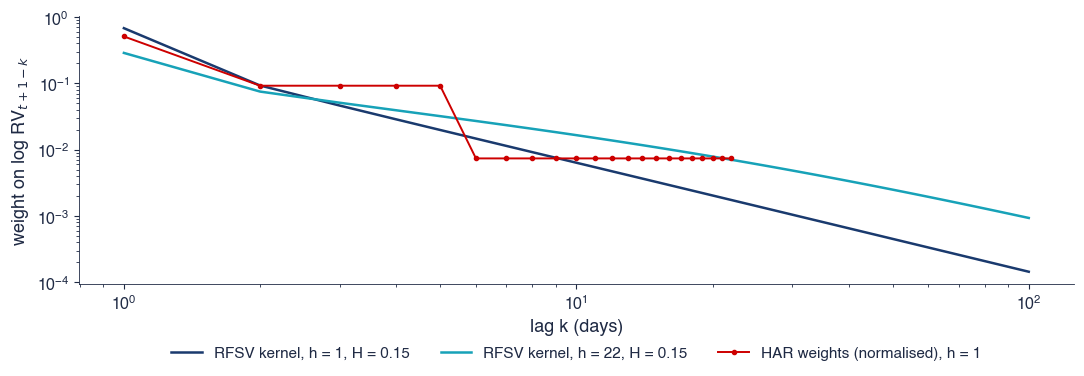

{'H': 0.14901172768561718, '1': {'w1': 0.6766527021448852, 'w5': 0.8634841582843281, 'w22': 0.9495043587578201, 'w100': 0.9856852367985062}, '22': {'w1': 0.2865741565363855, 'w5': 0.48332151824800523, 'w22': 0.711748574375749, 'w100': 0.8996601451772614}, 'har': {'w1': 0.5076474288983139, 'w5': 0.8749113065749528}}


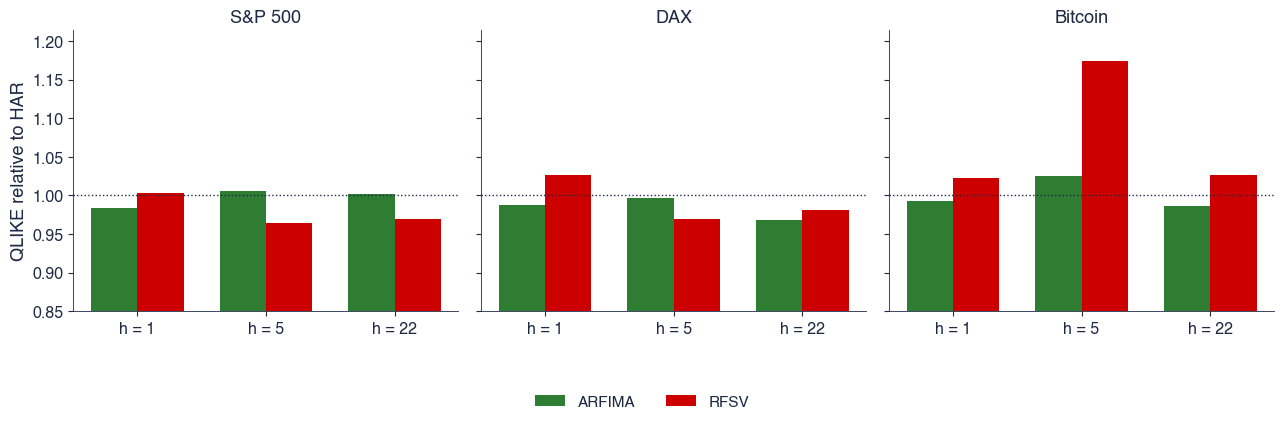

{'.SPX': {'1': (0.984, 1.003), '5': (1.006, 0.964), '22': (1.002, 0.969)}, '.GDAXI': {'1': (0.988, 1.026), '5': (0.996, 0.969), '22': (0.968, 0.982)}, 'btc': {'1': (0.992, 1.022), '5': (1.025, 1.174), '22': (0.986, 1.027)}}


In [12]:
@functools.lru_cache(maxsize=None)
def rfsv_kernel_c(H3, h, K=500):
    """rfsv_kernel with H rounded to three decimals (cached for the rolling evaluation)."""
    return rfsv_kernel(H3 / 1000, h, K)


def fig_rfsv_kernel(save_it=True, K=100):
    """Weights of the RFSV predictor (H of the S&P 500) for horizons 1 and 22 days, against the HAR weights."""
    x = 0.5 * np.log(rv_series('.SPX').values)
    H = gjr_scaling(x, LAGS, QS)['H']
    b, _ = har_fit_full(2 * x, 1)
    wh = har_ar_weights(b[1:])
    wh = wh / wh.sum()
    k = np.arange(1, K + 1)
    out = dict(H=H)
    fig, ax = plt.subplots(figsize=(11, 4.0))
    for h, c in ((1, st.MainBlue), (22, st.Teal)):
        w = rfsv_kernel_c(int(round(1000 * H)), h, 500)
        ax.loglog(k, w[:K], color=c, lw=1.8, label=f'RFSV kernel, h = {h}, H = {H:.2f}')
        out[str(h)] = dict(w1=float(w[0]), w5=float(w[:5].sum()), w22=float(w[:22].sum()), w100=float(w[:100].sum()))
    ax.loglog(np.arange(1, 23), wh, 'o-', ms=3, color=st.IDAred, label='HAR weights (normalised), h = 1')
    out['har'] = dict(w1=float(wh[0]), w5=float(wh[:5].sum()))
    ax.set_xlabel('lag k (days)')
    ax.set_ylabel('weight on log RV$_{t+1-k}$')
    st.legend_outside_bottom(ax, ncol=3, y=-0.18)
    plt.tight_layout()
    save('ats_ch10_rfsv_kernel', save_it)
    return out


def forecast_rv(rv, window=1000, refit=20, horizons=(1, 5, 22), d_a=A_BW):
    """Rolling out-of-sample forecasts of RV_{t+h} (a single day h ahead) from three models of y = log RV:
    HAR (direct regression for each h), ARFIMA(0, d, 0) (local Whittle d, AR(infinity) iterated), RFSV (Gatheral,
    Jaisson and Rosenbaum 2018: H and nu from the window's variogram, kernel predictor, lognormal correction).
    Level forecasts: HAR and ARFIMA exp(mean + variance/2); RFSV exp(mean + 2 c nu^2 h^(2H)).
    Returns a DataFrame with the target and the forecasts of each model and horizon."""
    y = np.log(np.asarray(rv, float))
    n = len(y)
    H_max = max(horizons)
    rows = []
    par = {}
    for t in range(window - 1, n - H_max):
        if (t - window + 1) % refit == 0:
            Y = y[t - window + 1:t + 1]
            mu = Y.mean()
            tt, X = har_design(Y)
            har = {}
            for h in horizons:
                keep = tt + h < len(Y)
                b = np.linalg.lstsq(X[keep], Y[tt[keep] + h], rcond=None)[0]
                har[h] = (b, float(np.var(Y[tt[keep] + h] - X[keep] @ b)))
            d = local_whittle(Y, bandwidth(window, d_a))[0]
            d = min(d, 0.49)
            pw = frac_weights(d, window + H_max + 1)
            e = frac_diff(Y - mu, d)[50:]
            s2e = float(e.var())
            psi = np.array([1.0] + list(np.cumprod((np.arange(1, H_max) - 1 + d) / np.arange(1, H_max))))
            g = gjr_scaling(0.5 * Y, LAGS, QS)
            H = min(max(g['H'], 0.01), 0.49)
            ker = {h: rfsv_kernel_c(int(round(1000 * H)), h, 500) for h in horizons}
            par = dict(har=har, mu=mu, pw=pw, s2e=s2e, psi=psi, H=H, nu=g['nu'], ker=ker, d=d)
        Y = y[t - window + 1:t + 1]
        row = dict(t=t)
        # HAR
        s = np.cumsum(np.concatenate([[0.0], Y]))
        xr = np.array([1.0, Y[-1], (s[-1] - s[-6]) / 5, (s[-1] - s[-23]) / 22])
        # ARFIMA: iterate the AR(infinity) recursion
        hist = list(Y - par['mu'])
        fc = []
        for k in range(H_max):
            hh = np.array(hist[::-1])
            nxt = -par['pw'][1:len(hh) + 1] @ hh
            fc.append(nxt)
            hist.append(nxt)
        for h in horizons:
            b, v = par['har'][h]
            mh = xr @ b
            row[f'har_l{h}'] = mh
            row[f'har_{h}'] = np.exp(mh + v / 2)
            ma = par['mu'] + fc[h - 1]
            va = par['s2e'] * np.sum(par['psi'][:h] ** 2)
            row[f'arf_l{h}'] = ma
            row[f'arf_{h}'] = np.exp(ma + va / 2)
            w = par['ker'][h]
            mr = w @ Y[::-1][:len(w)]
            row[f'rfsv_l{h}'] = mr
            row[f'rfsv_{h}'] = np.exp(mr + 2 * rfsv_c(par['H']) * par['nu'] ** 2 * h ** (2 * par['H']))
            row[f'y{h}'] = y[t + h]
        row['H'] = par['H']
        row['d'] = par['d']
        rows.append(row)
    return pd.DataFrame(rows)


def evaluate_forecasts(df, horizons=(1, 5, 22)):
    """Average QLIKE (levels) and MSE (logs) of the three models; DM statistics of ARFIMA and RFSV against HAR."""
    out = {}
    for h in horizons:
        rv = np.exp(df[f'y{h}'].values)
        r = {}
        for mdl in ('har', 'arf', 'rfsv'):
            r[mdl] = dict(qlike=float(qlike(rv, df[f'{mdl}_{h}'].values).mean()),
                          mse=float(np.mean((df[f'y{h}'] - df[f'{mdl}_l{h}']) ** 2)))
        for mdl in ('arf', 'rfsv'):
            r[mdl]['dm_q'] = dm_stat(qlike(rv, df[f'{mdl}_{h}'].values), qlike(rv, df[f'har_{h}'].values), h)
            r[mdl]['dm_m'] = dm_stat((df[f'y{h}'] - df[f'{mdl}_l{h}']) ** 2, (df[f'y{h}'] - df[f'har_l{h}']) ** 2, h)
            r[mdl]['rel_q'] = r[mdl]['qlike'] / r['har']['qlike']
            r[mdl]['rel_m'] = r[mdl]['mse'] / r['har']['mse']
        out[str(h)] = r
    return out


def run_forecasts():
    if 'fc' not in _MEM:
        res = {}
        for k in FC_ASSETS:
            s = rv_series(k)
            df = forecast_rv(s.values, **FC)
            df['date'] = s.index[df['t'].values]
            res[k] = df
        _MEM['fc'] = res
    return _MEM['fc']


def fig_forecast(save_it=True):
    """Relative QLIKE (model / HAR) of ARFIMA and RFSV forecasts of RV at 1, 5 and 22 days; DM significance."""
    res = run_forecasts()
    out = {}
    fig, axs = plt.subplots(1, 3, figsize=(13, 3.9), sharey=True)
    for ax, (k, lab) in zip(axs, FC_ASSETS.items()):
        df = res[k]
        ev = evaluate_forecasts(df, FC['horizons'])
        out[k] = dict(eval=ev, T=len(df), start=str(df['date'].iloc[0].date()), end=str(df['date'].iloc[-1].date()),
                      H_med=float(df['H'].median()), H_min=float(df['H'].min()), H_max=float(df['H'].max()),
                      d_med=float(df['d'].median()))
        x = np.arange(len(FC['horizons']))
        for i, (mdl, c, ml) in enumerate((('arf', st.Forest, 'ARFIMA'), ('rfsv', st.IDAred, 'RFSV'))):
            vals = [ev[str(h)][mdl]['rel_q'] for h in FC['horizons']]
            bars = ax.bar(x + (i - 0.5) * 0.36, vals, 0.36, color=c, label=ml)
            for j, h in enumerate(FC['horizons']):
                p = ev[str(h)][mdl]['dm_q'][1]
                if p < 0.05:
                    ax.text(x[j] + (i - 0.5) * 0.36, vals[j] + 0.004, '*', ha='center', color=st.DarkText, fontsize=13)
        ax.axhline(1, color=st.DarkText, ls=':', lw=1)
        ax.set_xticks(x)
        ax.set_xticklabels([f'h = {h}' for h in FC['horizons']])
        ax.set_title(lab)
        lo = min(ev[str(h)][m]['rel_q'] for h in FC['horizons'] for m in ('arf', 'rfsv'))
        hi = max(ev[str(h)][m]['rel_q'] for h in FC['horizons'] for m in ('arf', 'rfsv'))
        ax.set_ylim(min(0.85, lo - 0.03), max(1.1, hi + 0.04))
    axs[0].set_ylabel('QLIKE relative to HAR')
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    plt.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch10_forecast', save_it)
    return out


print(fig_rfsv_kernel(save_it=False))
r = fig_forecast(save_it=False)
print({k: {h: (round(v['eval'][h]['arf']['rel_q'], 3), round(v['eval'][h]['rfsv']['rel_q'], 3)) for h in v['eval']} for k, v in r.items()})

## 8. AI mini-case: how robust is "H of order 0.1"?

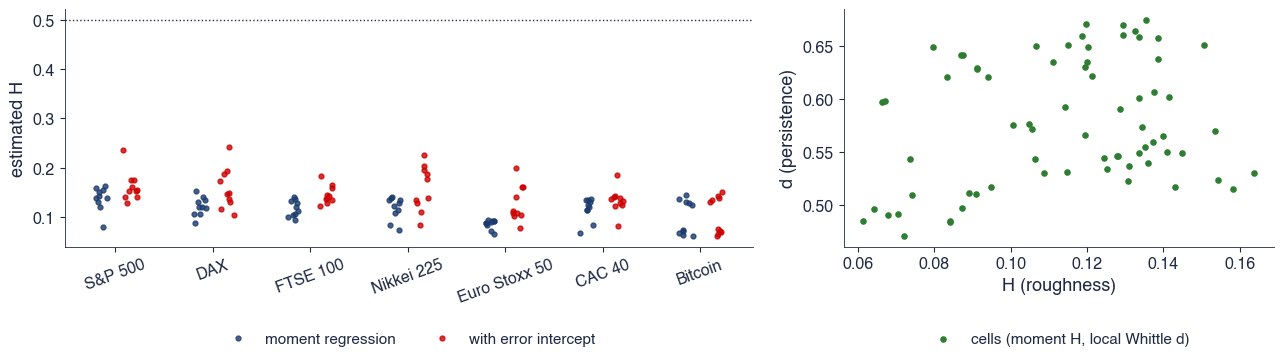

{'n': 140, 'n_cells': 70, 'H_min': 0.06136688968283453, 'H_max': 0.2420400794732003, 'H_med': 0.13054225266072378, 'share02': 0.9642857142857143, 'share03': 1.0, 'H_med_mom': 0.11954837062960263, 'H_med_int': 0.13919948251446018, 'd_min': 0.4706622472972532, 'd_max': 0.6750104691276475, 'd_med': 0.5707476186441001, 'corr': 0.24397833212725456}


In [13]:
def fig_ai_case(save_it=True):
    """``Volatility is rough'': H for 7 assets x 5 realised measures x 2 estimators x 2 halves of the sample;
    local Whittle d of log RV in the same cells."""
    rows = []
    for k in list(OMI_NAMES) + ['btc']:
        for col in AI_MEASURES['btc' if k == 'btc' else 'omi']:
            s = rv_series(k, col)
            half = len(s) // 2
            for part, ss in (('first half', s.iloc[:half]), ('second half', s.iloc[half:])):
                x = 0.5 * np.log(ss.values)
                rows.append(dict(asset=OMI_NAMES.get(k, 'Bitcoin'), measure=col, part=part, est='moments',
                                 H=gjr_scaling(x, LAGS, QS)['H'], d=local_whittle(2 * x, bandwidth(len(x), A_BW))[0]))
                rows.append(dict(asset=OMI_NAMES.get(k, 'Bitcoin'), measure=col, part=part, est='intercept',
                                 H=h_with_noise(x, LAGS)['H'], d=np.nan))
    t = pd.DataFrame(rows)
    assets = list(dict.fromkeys(t['asset']))
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.0), gridspec_kw=dict(width_ratios=[1.6, 1]))
    rng = np.random.default_rng(SEED)
    for est, c, lab in (('moments', st.MainBlue, 'moment regression'), ('intercept', st.IDAred, 'with error intercept')):
        tt = t[t['est'] == est]
        xs = np.array([assets.index(a) for a in tt['asset']]) + (0.15 if est == 'intercept' else -0.15) + rng.uniform(-0.08, 0.08, len(tt))
        axs[0].plot(xs, tt['H'], 'o', ms=3.5, color=c, alpha=0.8, label=lab)
    axs[0].axhline(0.5, color=st.DarkText, ls=':', lw=1)
    axs[0].set_xticks(range(len(assets)))
    axs[0].set_xticklabels(assets, rotation=20)
    axs[0].set_ylabel('estimated H')
    st.legend_outside_bottom(axs[0], ncol=2, y=-0.3)
    dd = t[t['est'] == 'moments']
    axs[1].scatter(dd['H'], dd['d'], s=14, color=st.Forest, label='cells (moment H, local Whittle d)')
    axs[1].set_xlabel('H (roughness)')
    axs[1].set_ylabel('d (persistence)')
    st.legend_outside_bottom(axs[1], ncol=1, y=-0.3)
    plt.tight_layout()
    save('ats_ch10_ai_case', save_it)
    H = t['H'].values
    return dict(n=int(len(t)), n_cells=int(len(t) // 2), H_min=float(H.min()), H_max=float(H.max()), H_med=float(np.median(H)),
                share02=float(np.mean(H < 0.2)), share03=float(np.mean(H < 0.3)),
                H_med_mom=float(t[t['est'] == 'moments']['H'].median()), H_med_int=float(t[t['est'] == 'intercept']['H'].median()),
                d_min=float(dd['d'].min()), d_max=float(dd['d'].max()), d_med=float(dd['d'].median()),
                corr=float(np.corrcoef(dd['H'], dd['d'])[0, 1]))


print(fig_ai_case(save_it=False))

## Exercises

1. Add the Qu test with m = n^0.75 and eps = 0.05 to the inflation analysis and compare.
2. Add lags (k = 1) to the FCVAR of log RV and log VIX^2 and re-estimate (d, b).
3. Replace the moment estimator of H in the RFSV forecasts by the estimator with an error intercept.